# Confusion Matrices

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Reusable Code for each FM

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ====================================================================
# Configuration
# ====================================================================
RESULTS_BASE = Path('/content/drive/MyDrive/infra_fm/results')

# (subdir, file_prefix, FM label, default cmap)
FM_CONFIGS = {
    'croma':       ('fm_eval_croma_v2_spatial',          'croma_v2',         'CROMA',             'Oranges'),
    'alphaearth':  ('fm_eval_alphaearth_v2_spatial',     'alphaearth_v2',    'AlphaEarth',        'Oranges'),
    'satlas_s1':   ('fm_eval_satlas_s1_finetune_v1',      'satlas_s1_finetune_v1',     'SatlasPretrain S1', 'Oranges'),         # altered for finetune test
    'satlas_s2':   ('fm_eval_satlas_s2_finetune_v1',      'satlas_s2_finetune_v1',     'SatlasPretrain S2', 'Oranges'),
    'prithvi':     ('fm_eval_prithvi_v2_spatial',        'prithvi_v2',       'Prithvi-EO-2.0',    'Oranges'),
    'resnet':      ('fm_eval_resnet18_supervised_v1',    'resnet18_supervised_v1', 'ResNet-18 (supervised)', 'Oranges')
}

CLASS_NAMES = [
    'energy.transmission.substation',
    'energy.distribution.substation',
    'energy.distribution.other',
    'energy.generation.power_plant',
    'energy.generation.solar_farm',
    'energy.generation.wind_farm',
    'water.wastewater.plant',
    'water.water_works',
    'water.storage_tank',
    'transport.airport',
    'transport.train_station',
    'transport.port_terminal',
    'telecom.data_center',
]

# Formal display names for figures (per Ed's feedback: no raw OSM-tag
# underscores/lowercase in plots -- use proper row/column labels).
CLASS_DISPLAY_NAMES = {
    'energy.transmission.substation': 'Transmission Substation',
    'energy.distribution.substation': 'Distribution Substation',
    'energy.distribution.other': 'Distribution (Other)',
    'energy.generation.power_plant': 'Power Plant',
    'energy.generation.solar_farm': 'Solar Farm',
    'energy.generation.wind_farm': 'Wind Farm',
    'water.wastewater.plant': 'Wastewater Plant',
    'water.water_works': 'Water Works',
    'water.storage_tank': 'Storage Tank',
    'transport.airport': 'Airport',
    'transport.train_station': 'Train Station',
    'transport.port_terminal': 'Port Terminal',
    'telecom.data_center': 'Data Center',
}
SHORT_NAMES = [CLASS_DISPLAY_NAMES[n] for n in CLASS_NAMES]
DEFAULT_SEEDS = [314, 271, 161]

# Legacy class-name remap. `water.treatment.plant` was the previous name
# for what is now `water.water_works` (ontology.py rename). Aggregate
# JSONs produced before the rename still carry the old string on
# `per_class_f1[i]['class']`. Per-seed JSONs use index-based float lists
# (no class-name strings), so this remap is only needed by code that
# keys aggregate JSONs by class-name string. Safe to call repeatedly.
LEGACY_CLASS_REMAP = {'water.treatment.plant': 'water.water_works'}


def apply_legacy_class_remap(agg):
    """Rewrite legacy class-name strings in an aggregate JSON in place.
    No-op on already-renamed aggregates. Returns the same dict for chaining.
    """
    for entry in agg.get('per_class_f1', []):
        if entry.get('class') in LEGACY_CLASS_REMAP:
            entry['class'] = LEGACY_CLASS_REMAP[entry['class']]
    return agg


# ====================================================================
# Internal helpers
# ====================================================================
def _load_seed_results(fm, seeds):
    """Load per-seed JSONs for a given FM. Returns (data, missing, label, default_cmap)."""
    if fm not in FM_CONFIGS:
        raise ValueError(
            f'Unknown FM "{fm}". Available: {list(FM_CONFIGS.keys())}'
        )
    subdir, file_prefix, fm_label, default_cmap = FM_CONFIGS[fm]
    results_dir = RESULTS_BASE / subdir

    seed_data = {}
    missing = []
    for seed in seeds:
        json_path = results_dir / f'{file_prefix}_seed{seed}_results.json'
        if not json_path.exists():
            missing.append(seed)
            continue
        with open(json_path) as f:
            r = json.load(f)
        test = r['finetune']['test']
        cm = np.array(test['confusion'], dtype=np.int64)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm.astype(np.float64), row_sums,
                             out=np.zeros_like(cm, dtype=np.float64),
                             where=row_sums > 0)
        seed_data[seed] = {
            'cm': cm,
            'cm_norm': cm_norm,
            'macro_f1': test['macro_f1'],
            'acc': test['acc'],
            'n': int(cm.sum()),
            'per_class_f1': test['per_class_f1'],
        }
    return seed_data, missing, fm_label, default_cmap


def _draw_confusion(ax, cm, cm_norm, title, cmap='Oranges'):
    """Draw a single confusion matrix on a given axes."""
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(SHORT_NAMES, rotation=45, ha='right', fontsize=14)
    ax.set_yticklabels(SHORT_NAMES, fontsize=14)
    ax.set_xlabel('Predicted', fontsize=17)
    ax.set_ylabel('True', fontsize=17)
    ax.set_title(title, fontsize=18)
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            v = cm_norm[i, j]
            count = cm[i, j]
            if v > 0.01:
                color = 'white' if v > 0.5 else 'black'
                ax.text(j, i, f'{count}\n({v:.0%})', ha='center', va='center',
                        color=color, fontsize=12)
    return im


def _print_summary(seed_data, seeds, fm_label):
    """Print per-class and macro F1 summary across seeds."""
    n_seeds = len(seeds)
    print(f'\n{fm_label} v2 — per-class F1 across {n_seeds} seed(s): {seeds}')
    header_seeds = '  '.join([f'{f"seed {s}":<10s}' for s in seeds])
    summary_col = '  mean ± std' if n_seeds >= 2 else ''
    print(f'{"":<3} {"class":<34s} {header_seeds}{summary_col}')
    print('-' * (38 + 12 * n_seeds + (15 if n_seeds >= 2 else 0)))
    for i, name in enumerate(CLASS_NAMES):
        vals = [seed_data[s]['per_class_f1'][i] for s in seeds]
        row = (f'[{i:>2d}] {name:<34s} '
               + '  '.join([f'{v:<10.4f}' for v in vals]))
        if n_seeds >= 2:
            m, sd = float(np.mean(vals)), float(np.std(vals, ddof=0))
            row += f'  {m:.4f} ± {sd:.4f}'
        print(row)

    macros = [seed_data[s]['macro_f1'] for s in seeds]
    print(f'\nMacro F1 across seeds: {[f"{m:.4f}" for m in macros]}')
    if n_seeds >= 2:
        print(f'Mean ± std:           '
              f'{np.mean(macros):.4f} ± {np.std(macros, ddof=0):.4f}')



# ====================================================================
# Aggregate confusion matrix (main paper figure)
# ====================================================================
def confusion_matrix_aggregate(fm, seeds=None, show_summary=True, cmap=None):
    """
    Display a single aggregate confusion matrix for an FM by summing
    raw counts across seeds before row-normalizing.

    Use this for the main paper body. Use confusion_matrix() for the
    per-seed appendix figures. Use save_all_confusion_matrices() to
    write PNGs to disk for all FMs at once.

    Parameters
    ----------
    fm : str
        FM key in FM_CONFIGS.
    seeds : list[int] or None
        Seeds to aggregate over. Defaults to [314, 271, 161].
    show_summary : bool
        If True, prints per-class F1 summary.
    cmap : str or None
        Matplotlib colormap. Falls back to per-FM default.

    Returns
    -------
    seed_data : dict
        Loaded per-seed data.
    """
    if seeds is None:
        seeds = DEFAULT_SEEDS

    seed_data, missing, fm_label, default_cmap = _load_seed_results(fm, seeds)
    if missing:
        print(f'NOTE: missing seeds {missing} for {fm_label} — '
              f'showing available seeds only')

    available_seeds = [s for s in seeds if s in seed_data]
    n_seeds = len(available_seeds)
    if n_seeds == 0:
        raise RuntimeError(
            f'No seed results found for {fm_label}. '
            f'Checked: {RESULTS_BASE / FM_CONFIGS[fm][0]}'
        )

    effective_cmap = cmap if cmap is not None else default_cmap

    # Sum raw counts across seeds, then row-normalize once.
    # This is correct -- do NOT average normalized matrices.
    cm_sum = sum(seed_data[s]['cm'] for s in available_seeds)
    row_sums = cm_sum.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_sum.astype(np.float64), row_sums,
                         out=np.zeros_like(cm_sum, dtype=np.float64),
                         where=row_sums > 0)

    # Aggregate macro F1: mean of per-seed macro F1 scores
    macro_f1_mean = float(np.mean([seed_data[s]['macro_f1'] for s in available_seeds]))
    macro_f1_std  = float(np.std( [seed_data[s]['macro_f1'] for s in available_seeds], ddof=0))
    n_total = int(cm_sum.sum())

    title = (f'n={n_total} across {n_seeds} seeds\n'
             f'macro F1={macro_f1_mean:.3f} ± {macro_f1_std:.3f}')

    fig, ax = plt.subplots(1, 1, figsize=(13, 12.5),
                           constrained_layout=True)
    im = _draw_confusion(ax, cm_sum, cm_norm, title, cmap=effective_cmap)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                 label='Row-normalized')
    fig.suptitle(f'{fm_label} — Aggregate Confusion Matrix',
                 fontsize=20, y=1.01)
    plt.show()

    if show_summary:
        _print_summary(seed_data, available_seeds, fm_label)

    return seed_data


# ====================================================================
# Public entry point
# ====================================================================
def confusion_matrix(fm, seeds=None, show_summary=True, cmap=None):
    """
    Display per-seed confusion matrices stacked vertically for an FM.

    Parameters
    ----------
    fm : str
        FM key in FM_CONFIGS. Options: 'croma', 'alphaearth', 'satlas_s1',
        'satlas_s2', 'prithvi', 'resnet'.
    seeds : list[int] or None
        Seeds to display. Defaults to [314, 271, 161]. Missing seeds
        are silently skipped with a note.
    show_summary : bool
        If True, prints per-class F1 table across seeds + macro F1
        summary after the plot.
    cmap : str or None
        Matplotlib colormap name. If None, uses the per-FM default
        from FM_CONFIGS.

    Returns
    -------
    seed_data : dict
        Loaded per-seed data, in case you want further analysis.
    """
    if seeds is None:
        seeds = DEFAULT_SEEDS

    seed_data, missing, fm_label, default_cmap = _load_seed_results(fm, seeds)
    if missing:
        print(f'NOTE: missing seeds {missing} for {fm_label} — '
              f'showing available seeds only')

    available_seeds = [s for s in seeds if s in seed_data]
    n_seeds = len(available_seeds)
    if n_seeds == 0:
        raise RuntimeError(
            f'No seed results found for {fm_label}. '
            f'Checked: {RESULTS_BASE / FM_CONFIGS[fm][0]}'
        )

    effective_cmap = cmap if cmap is not None else default_cmap

    # One figure per seed -- easier to place individually in the manuscript.
    for k, seed in enumerate(available_seeds):
        d = seed_data[seed]
        title = (
                 f'n={d["n"]}, macro F1={d["macro_f1"]:.3f}, '
                 f'acc={d["acc"]:.3f}')

        fig, ax = plt.subplots(1, 1, figsize=(13, 12.5),
                               constrained_layout=True)
        im = _draw_confusion(ax, d['cm'], d['cm_norm'], title,
                              cmap=effective_cmap)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                     label='Row-normalized')
        fig.suptitle(f'{fm_label} — Seed {seed} Confusion Matrix',
                     fontsize=20, y=1.01)
        plt.show()

    if show_summary:
        _print_summary(seed_data, available_seeds, fm_label)

    return seed_data


# ====================================================================
# Bulk save-to-disk (Task 3: regenerate all figures with 'Water Works')
# ====================================================================
def save_all_confusion_matrices(fms=None, seeds=None, cmap='Oranges',
                                dpi=150, verbose=True):
    """Write every confusion-matrix PNG (aggregate + per-seed) for every FM
    to that FM's results directory. Does NOT render inline — this is the
    write-to-disk path. Use confusion_matrix() / confusion_matrix_aggregate()
    for inline preview.

    Filenames written into each `RESULTS_BASE / FM_CONFIGS[fm].subdir`:
      - confusion_matrix_{file_prefix}_aggregate.png   (1 per FM)
      - confusion_matrix_{file_prefix}_seed{seed}.png  (1 per seed)

    So a full run (6 FMs × 3 seeds + 6 aggregates) writes 24 PNGs.

    Parameters
    ----------
    fms : list[str] or None
        FM keys to render. Defaults to all six in FM_CONFIGS.
    seeds : list[int] or None
        Seeds to render. Defaults to [314, 271, 161].
    cmap : str
        Matplotlib colormap. Defaults to 'Oranges' (manuscript style).
    dpi : int
        Save resolution. 150 matches the training-notebook default.
    verbose : bool
        Print each save path.

    Returns
    -------
    list of (Path, str) tuples: (written_path, status) where status is
    'aggregate' or 'seed{n}'. Empty list if nothing was writable.
    """
    if fms is None:
        fms = list(FM_CONFIGS.keys())
    if seeds is None:
        seeds = DEFAULT_SEEDS

    written = []
    for fm in fms:
        subdir, file_prefix, fm_label, _ = FM_CONFIGS[fm]
        out_dir = RESULTS_BASE / subdir
        out_dir.mkdir(parents=True, exist_ok=True)

        seed_data, missing, _, _ = _load_seed_results(fm, seeds)
        if missing:
            print(f'[{fm_label}] missing seeds {missing} — skipping those')
        available = [s for s in seeds if s in seed_data]
        if not available:
            print(f'[{fm_label}] NO SEEDS AVAILABLE at {out_dir} — skipping FM')
            continue

        # --- Per-seed figures ---
        for seed in available:
            d = seed_data[seed]
            title = (
                     f'n={d["n"]}, macro F1={d["macro_f1"]:.3f}, '
                     f'acc={d["acc"]:.3f}')
            fig, ax = plt.subplots(1, 1, figsize=(13, 12.5),
                                   constrained_layout=True)
            im = _draw_confusion(ax, d['cm'], d['cm_norm'], title, cmap=cmap)
            fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                         label='Row-normalized')
            fig.suptitle(f'{fm_label} — Seed {seed} Confusion Matrix',
                         fontsize=20, y=1.01)
            path = out_dir / f'confusion_matrix_{file_prefix}_seed{seed}.png'
            fig.savefig(path, dpi=dpi, bbox_inches='tight')
            plt.close(fig)
            written.append((path, f'seed{seed}'))
            if verbose:
                print(f'  saved  {path}')

        # --- Aggregate figure ---
        cm_sum = sum(seed_data[s]['cm'] for s in available)
        row_sums = cm_sum.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm_sum.astype(np.float64), row_sums,
                             out=np.zeros_like(cm_sum, dtype=np.float64),
                             where=row_sums > 0)
        macros = [seed_data[s]['macro_f1'] for s in available]
        macro_mean = float(np.mean(macros))
        macro_std  = float(np.std(macros, ddof=0))
        title = (f'n={int(cm_sum.sum())} across {len(available)} seeds\n'
                 f'macro F1={macro_mean:.3f} ± {macro_std:.3f}')
        fig, ax = plt.subplots(1, 1, figsize=(13, 12.5),
                               constrained_layout=True)
        im = _draw_confusion(ax, cm_sum, cm_norm, title, cmap=cmap)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                     label='Row-normalized')
        fig.suptitle(f'{fm_label} — Aggregate Confusion Matrix',
                     fontsize=20, y=1.01)
        path = out_dir / f'confusion_matrix_{file_prefix}_aggregate.png'
        fig.savefig(path, dpi=dpi, bbox_inches='tight')
        plt.close(fig)
        written.append((path, 'aggregate'))
        if verbose:
            print(f'  saved  {path}\n')

    print(f'\nDone. Wrote {len(written)} PNG(s) across {len(fms)} FMs.')
    n_agg  = sum(1 for _, s in written if s == 'aggregate')
    n_seed = sum(1 for _, s in written if s.startswith('seed'))
    print(f'  aggregate: {n_agg}   per-seed: {n_seed}')
    return written


# ============================================================================
# Precision / recall / weighted-F1 helper
# ============================================================================
def compute_precision_recall_from_confusion(cm):
    """Per-class precision, recall, F1, plus weighted-F1 / macro-F1 / accuracy,
    computed from a confusion matrix.

    Verified against sklearn's precision_recall_fscore_support to <1e-10 on
    non-degenerate CMs (see the notebook's git history for the self-test).
    Zero-division-safe: any class with zero support gets recall=0/f1=0, and
    any class never predicted gets precision=0/f1=0.

    Parameters
    ----------
    cm : array-like of shape (n_classes, n_classes)
        cm[i, j] = count of samples with true class i predicted as class j.
        Diagonal = TP; row sums = support (true class); col sums = predicted.

    Returns
    -------
    dict with:
        'precision'   : np.ndarray (n_classes,) — TP / (TP + FP)
        'recall'      : np.ndarray (n_classes,) — TP / (TP + FN)
        'f1'          : np.ndarray (n_classes,) — 2·P·R / (P + R)
        'support'     : np.ndarray[int64] (n_classes,) — per-class row sum
        'weighted_f1' : float — Σ_c (support_c / total) · f1_c
        'macro_f1'    : float — mean(f1)
        'accuracy'    : float — sum(diag) / total
        'n_classes'   : int
        'total'       : int — sum of all CM entries
    """
    cm = np.asarray(cm, dtype=np.float64)
    if cm.ndim != 2 or cm.shape[0] != cm.shape[1]:
        raise ValueError(f'cm must be square 2-D; got shape {cm.shape}')
    n_classes = cm.shape[0]
    tp        = np.diag(cm)
    support   = cm.sum(axis=1)              # true-class counts (row sums)
    predicted = cm.sum(axis=0)              # predicted-class counts (col sums)
    precision = np.divide(tp, predicted, out=np.zeros(n_classes), where=predicted > 0)
    recall    = np.divide(tp, support,   out=np.zeros(n_classes), where=support   > 0)
    pr_sum    = precision + recall
    f1        = np.divide(2 * precision * recall, pr_sum,
                          out=np.zeros(n_classes), where=pr_sum > 0)
    total     = cm.sum()
    if total > 0:
        weights     = support / total
        weighted_f1 = float((weights * f1).sum())
        accuracy    = float(tp.sum() / total)
    else:
        weighted_f1 = 0.0
        accuracy    = 0.0
    return {
        'precision':   precision,
        'recall':      recall,
        'f1':          f1,
        'support':     support.astype(np.int64),
        'weighted_f1': weighted_f1,
        'macro_f1':    float(f1.mean()),
        'accuracy':    accuracy,
        'n_classes':   int(n_classes),
        'total':       int(total),
    }



## Satlas S1

NOTE: missing seeds [271, 161] for SatlasPretrain S1 — showing available seeds only


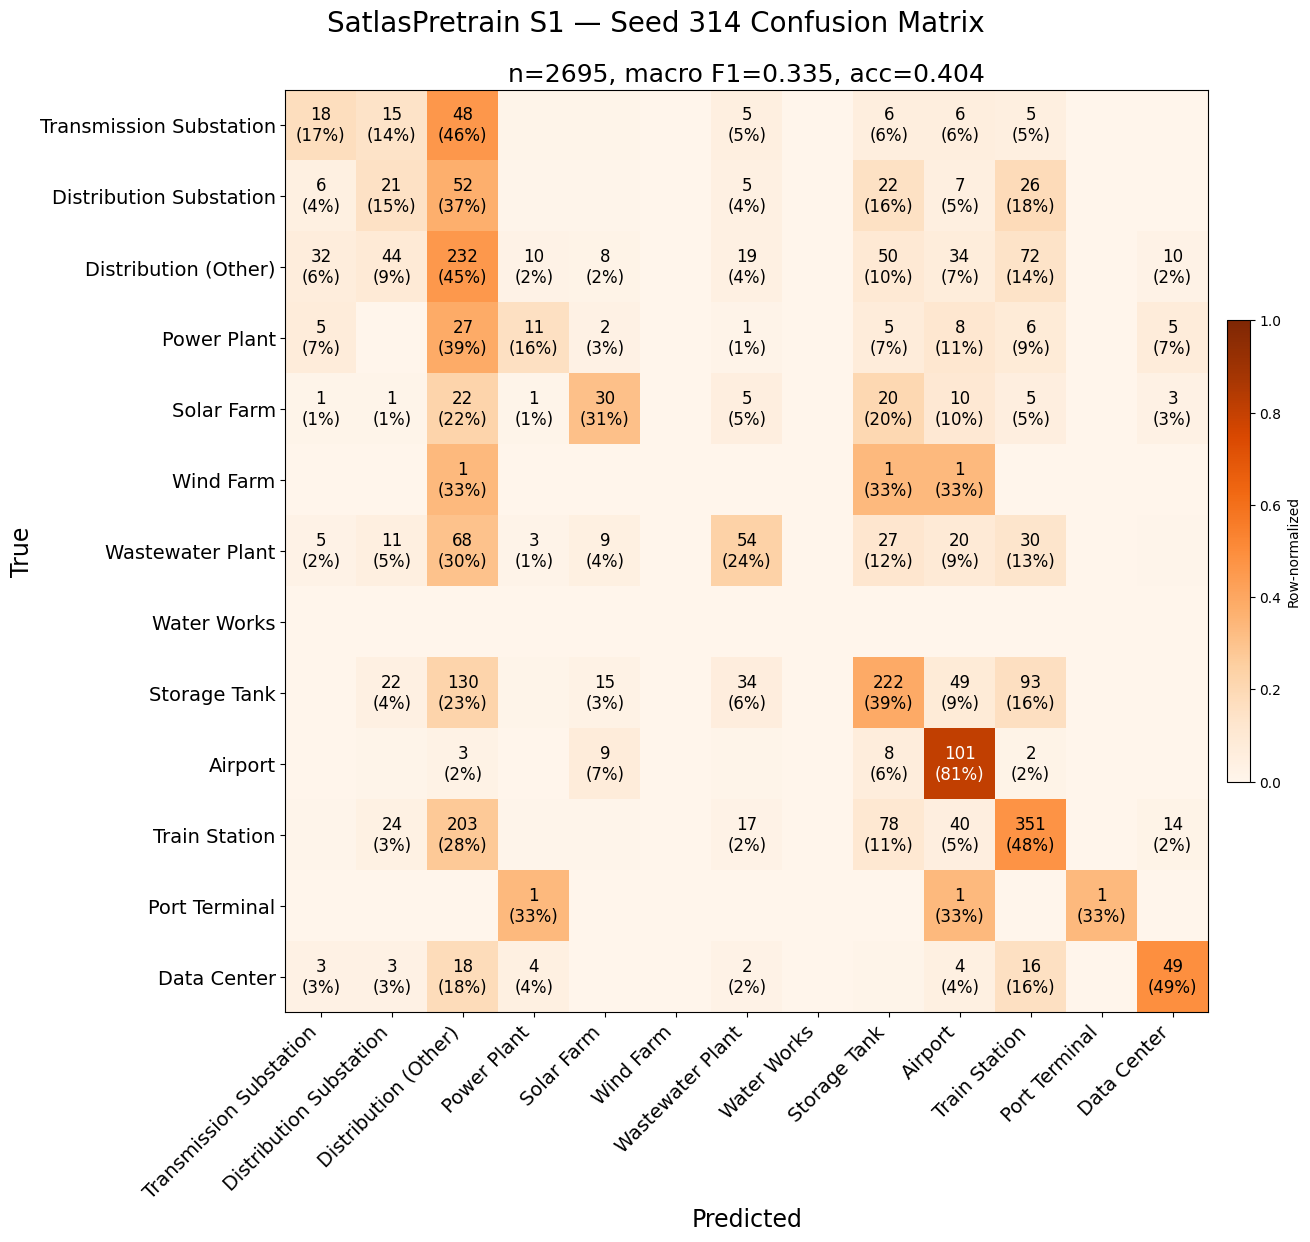


SatlasPretrain S1 v2 — per-class F1 across 1 seed(s): [314]
    class                              seed 314  
--------------------------------------------------
[ 0] energy.transmission.substation     0.2000    
[ 1] energy.distribution.substation     0.1484    
[ 2] energy.distribution.other          0.3529    
[ 3] energy.generation.power_plant      0.1982    
[ 4] energy.generation.solar_farm       0.3409    
[ 5] energy.generation.wind_farm        0.0000    
[ 6] water.wastewater.plant             0.2911    
[ 7] water.water_works                  0.0000    
[ 8] water.storage_tank                 0.4379    
[ 9] transport.airport                  0.4975    
[10] transport.train_station            0.5227    
[11] transport.port_terminal            0.5000    
[12] telecom.data_center                0.5326    

Macro F1 across seeds: ['0.3352']


{314: {'cm': array([[ 18,  15,  48,   1,   1,   0,   5,   0,   6,   6,   5,   0,   0],
         [  6,  21,  52,   1,   1,   0,   5,   0,  22,   7,  26,   0,   0],
         [ 32,  44, 232,  10,   8,   0,  19,   0,  50,  34,  72,   0,  10],
         [  5,   0,  27,  11,   2,   0,   1,   0,   5,   8,   6,   0,   5],
         [  1,   1,  22,   1,  30,   0,   5,   0,  20,  10,   5,   0,   3],
         [  0,   0,   1,   0,   0,   0,   0,   0,   1,   1,   0,   0,   0],
         [  5,  11,  68,   3,   9,   0,  54,   0,  27,  20,  30,   0,   1],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  2,  22, 130,   5,  15,   0,  34,   0, 222,  49,  93,   0,   2],
         [  0,   1,   3,   0,   9,   0,   1,   0,   8, 101,   2,   0,   0],
         [  3,  24, 203,   4,   3,   0,  17,   0,  78,  40, 351,   0,  14],
         [  0,   0,   0,   1,   0,   0,   0,   0,   0,   1,   0,   1,   0],
         [  3,   3,  18,   4,   0,   0,   2,   0,   1,   4,  16,   0,  49]]),

In [5]:
confusion_matrix('satlas_s1', cmap="Oranges")

## Satlas S2

NOTE: missing seeds [271, 161] for SatlasPretrain S2 — showing available seeds only


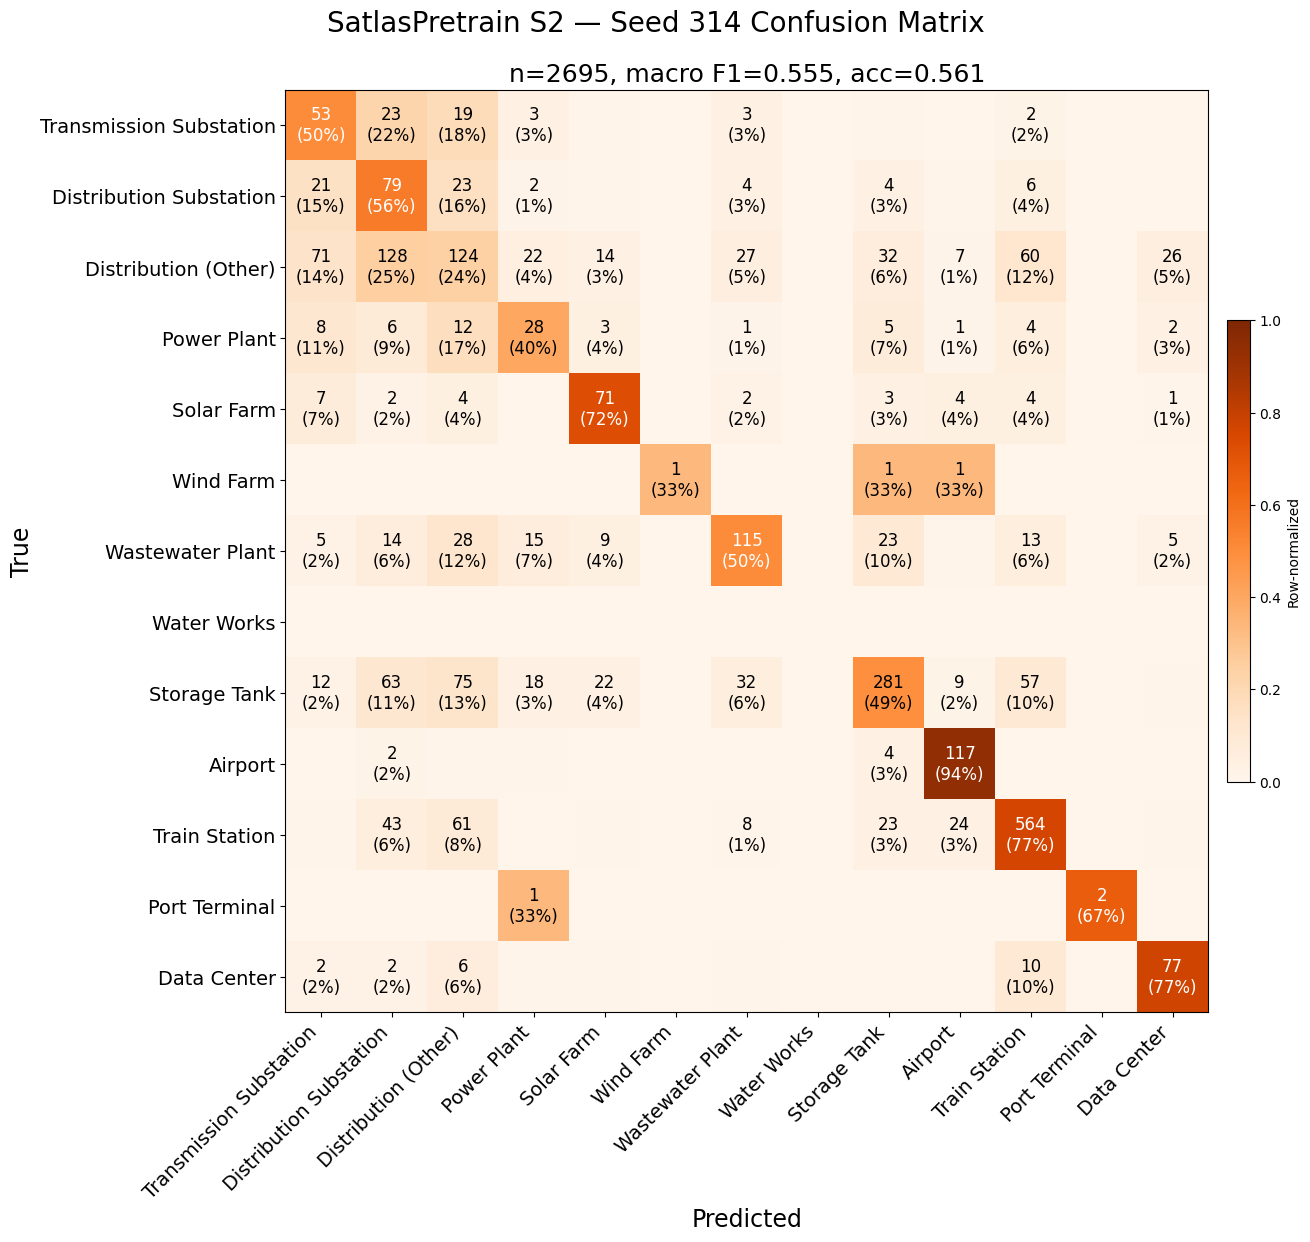


SatlasPretrain S2 v2 — per-class F1 across 1 seed(s): [314]
    class                              seed 314  
--------------------------------------------------
[ 0] energy.transmission.substation     0.3681    
[ 1] energy.distribution.substation     0.3141    
[ 2] energy.distribution.other          0.2870    
[ 3] energy.generation.power_plant      0.3436    
[ 4] energy.generation.solar_farm       0.6368    
[ 5] energy.generation.wind_farm        0.5000    
[ 6] water.wastewater.plant             0.5463    
[ 7] water.water_works                  0.0000    
[ 8] water.storage_tank                 0.5910    
[ 9] transport.airport                  0.8069    
[10] transport.train_station            0.7742    
[11] transport.port_terminal            0.8000    
[12] telecom.data_center                0.6968    

Macro F1 across seeds: ['0.5554']


{314: {'cm': array([[ 53,  23,  19,   3,   1,   0,   3,   0,   1,   0,   2,   0,   0],
         [ 21,  79,  23,   2,   1,   0,   4,   0,   4,   1,   6,   0,   0],
         [ 71, 128, 124,  22,  14,   0,  27,   0,  32,   7,  60,   0,  26],
         [  8,   6,  12,  28,   3,   0,   1,   0,   5,   1,   4,   0,   2],
         [  7,   2,   4,   0,  71,   0,   2,   0,   3,   4,   4,   0,   1],
         [  0,   0,   0,   0,   0,   1,   0,   0,   1,   1,   0,   0,   0],
         [  5,  14,  28,  15,   9,   0, 115,   0,  23,   1,  13,   0,   5],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [ 12,  63,  75,  18,  22,   0,  32,   0, 281,   9,  57,   0,   5],
         [  0,   2,   1,   1,   0,   0,   0,   0,   4, 117,   0,   0,   0],
         [  4,  43,  61,   2,   3,   0,   8,   0,  23,  24, 564,   0,   5],
         [  0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   2,   0],
         [  2,   2,   6,   1,   1,   0,   1,   0,   0,   0,  10,   0,  77]]),

In [3]:
confusion_matrix('satlas_s2', cmap="Oranges")

## CROMA 

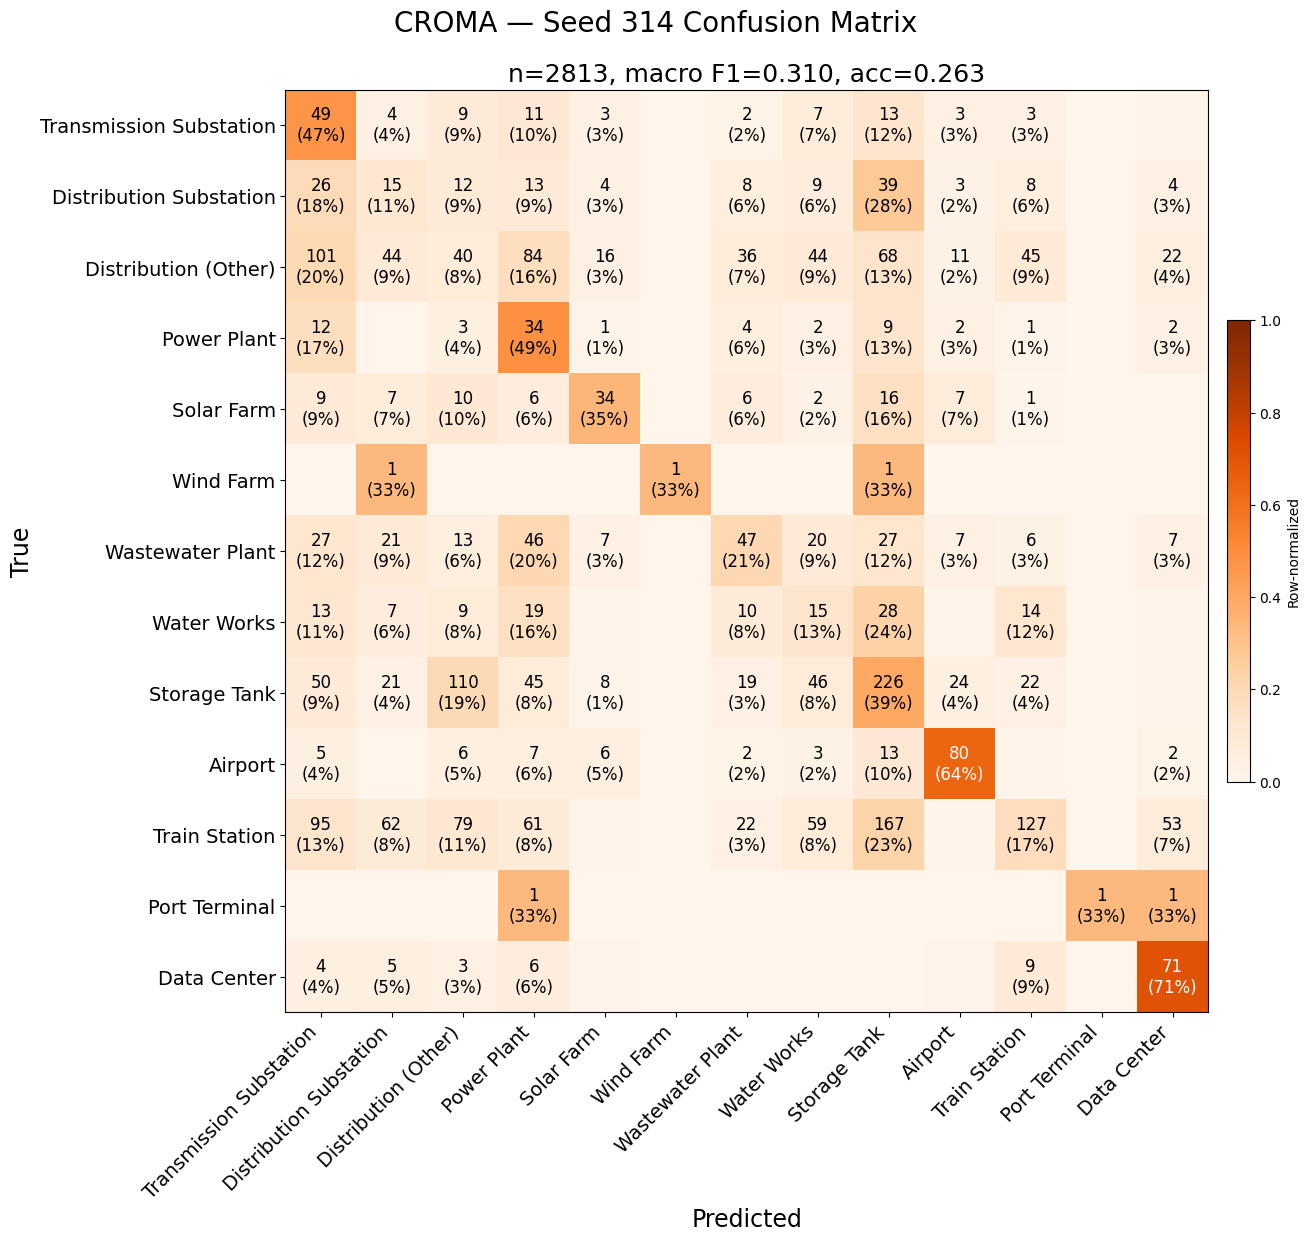

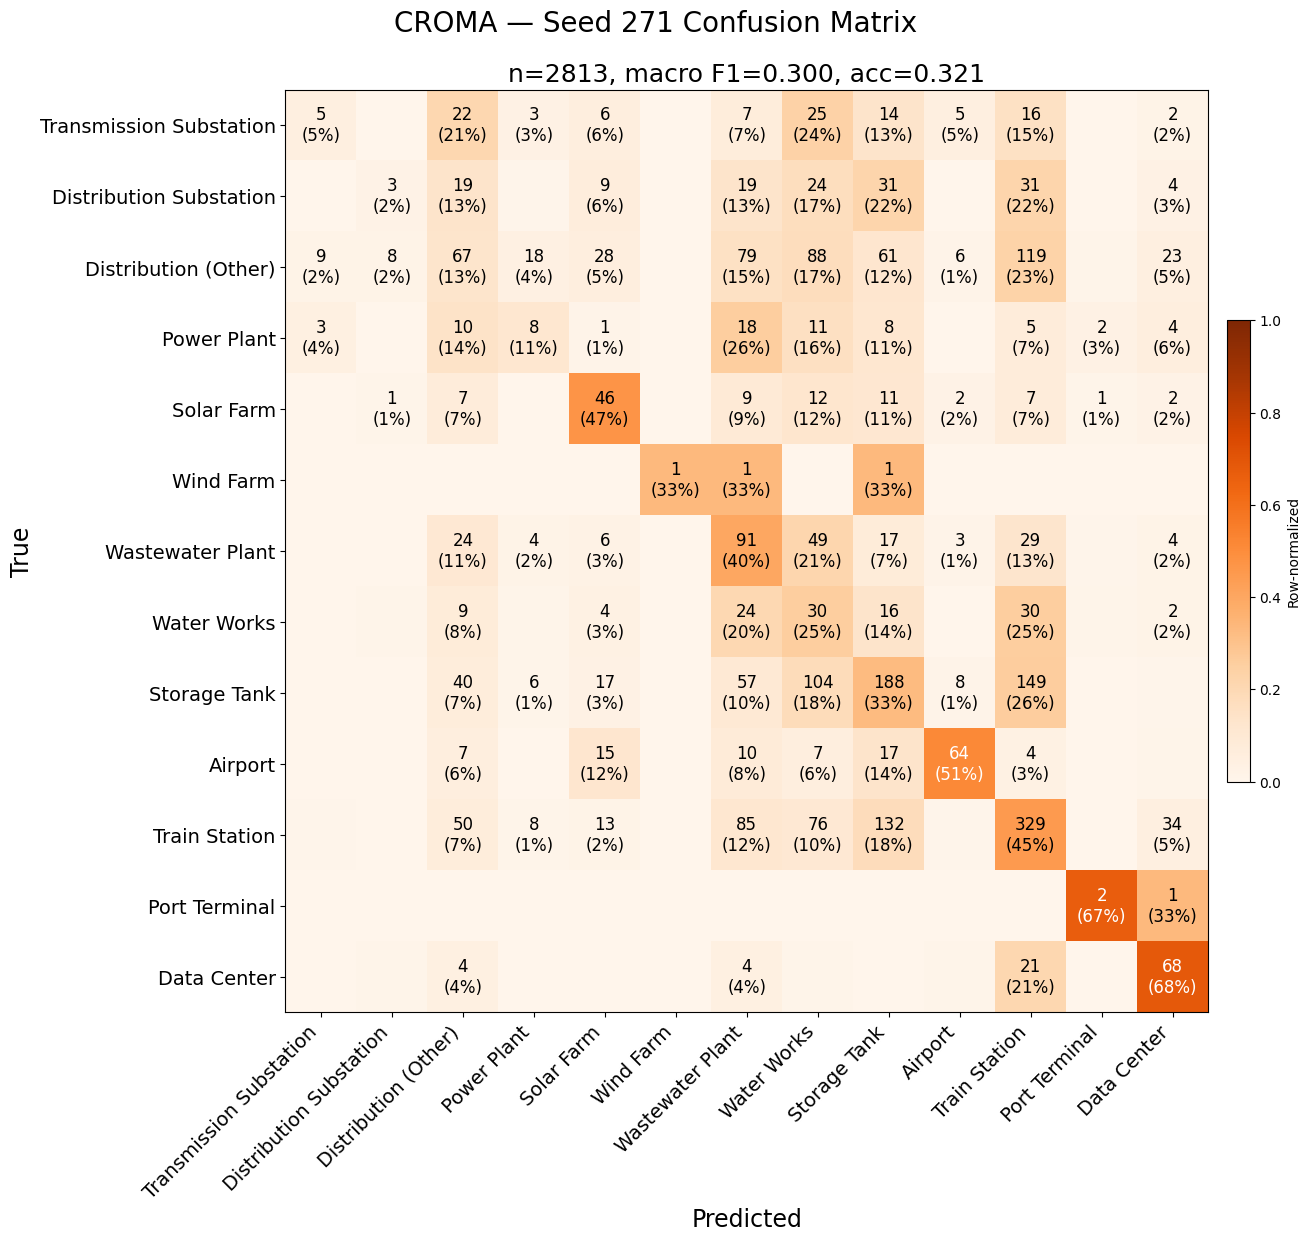

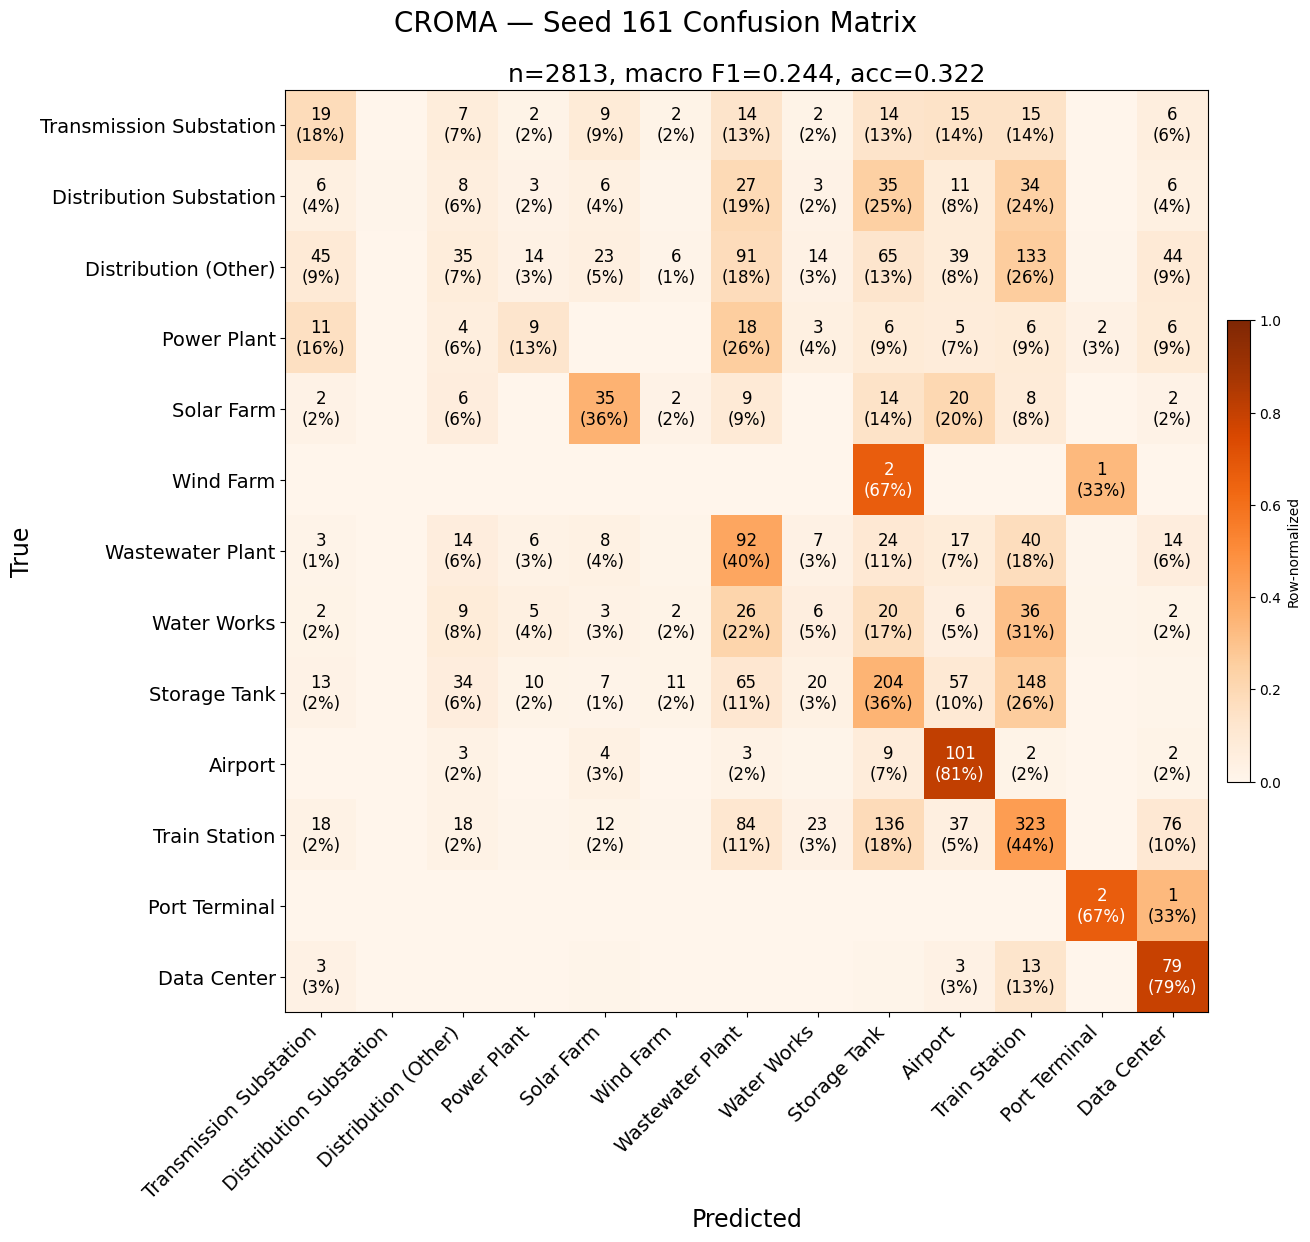


CROMA v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.1976      0.0781      0.1674      0.1477 ± 0.0507
[ 1] energy.distribution.substation     0.0915      0.0380      0.0141      0.0478 ± 0.0324
[ 2] energy.distribution.other          0.0994      0.1740      0.1079      0.1271 ± 0.0334
[ 3] energy.generation.power_plant      0.1687      0.1345      0.1452      0.1494 ± 0.0143
[ 4] energy.generation.solar_farm       0.3696      0.3786      0.3398      0.3627 ± 0.0166
[ 5] energy.generation.wind_farm        0.5000      0.5000      0.0000      0.3333 ± 0.2357
[ 6] water.wastewater.plant             0.2448      0.2880      0.2801      0.2709 ± 0.0188
[ 7] water.water_works                  0.0923      0.1101      0.0609      0.0878 ± 0.0203
[ 8] water.storage_tank      

{314: {'cm': array([[ 49,   4,   9,  11,   3,   0,   2,   7,  13,   3,   3,   0,   1],
         [ 26,  15,  12,  13,   4,   0,   8,   9,  39,   3,   8,   0,   4],
         [101,  44,  40,  84,  16,   0,  36,  44,  68,  11,  45,   0,  22],
         [ 12,   0,   3,  34,   1,   0,   4,   2,   9,   2,   1,   0,   2],
         [  9,   7,  10,   6,  34,   0,   6,   2,  16,   7,   1,   0,   0],
         [  0,   1,   0,   0,   0,   1,   0,   0,   1,   0,   0,   0,   0],
         [ 27,  21,  13,  46,   7,   0,  47,  20,  27,   7,   6,   0,   7],
         [ 13,   7,   9,  19,   1,   0,  10,  15,  28,   1,  14,   0,   1],
         [ 50,  21, 110,  45,   8,   0,  19,  46, 226,  24,  22,   0,   3],
         [  5,   0,   6,   7,   6,   0,   2,   3,  13,  80,   1,   0,   2],
         [ 95,  62,  79,  61,   5,   0,  22,  59, 167,   7, 127,   0,  53],
         [  0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   1,   1],
         [  4,   5,   3,   6,   1,   0,   0,   0,   0,   1,   9,   0,  71]]),

In [11]:
confusion_matrix('croma', cmap="Oranges")

## AlphaEarth

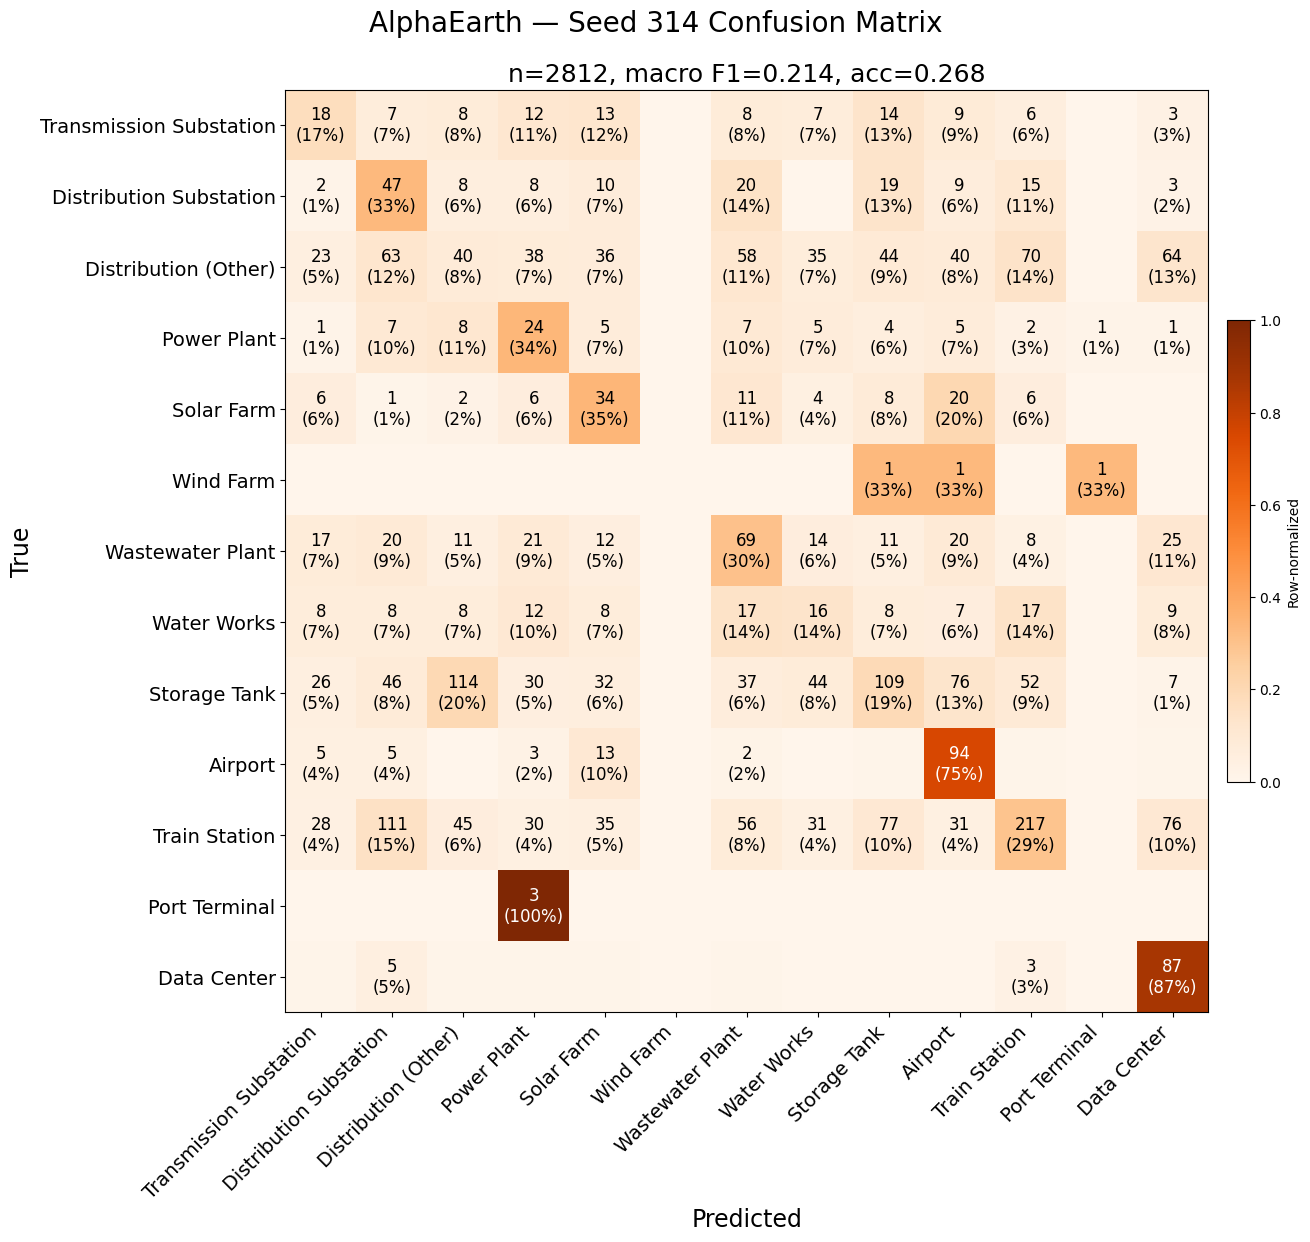

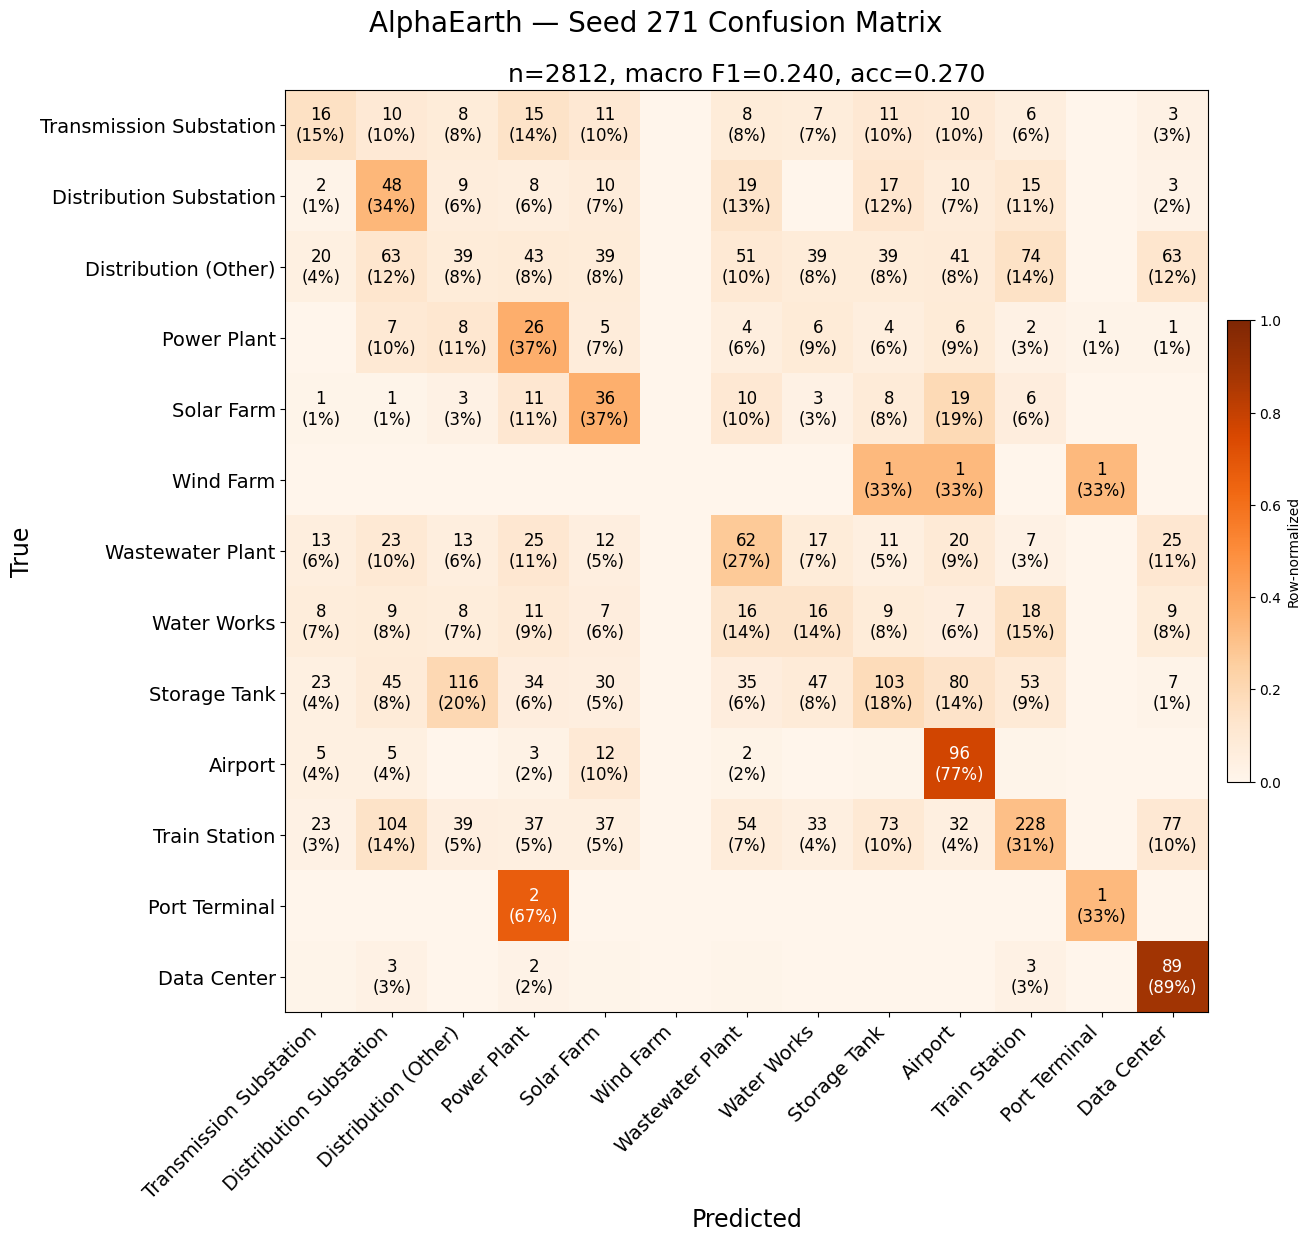

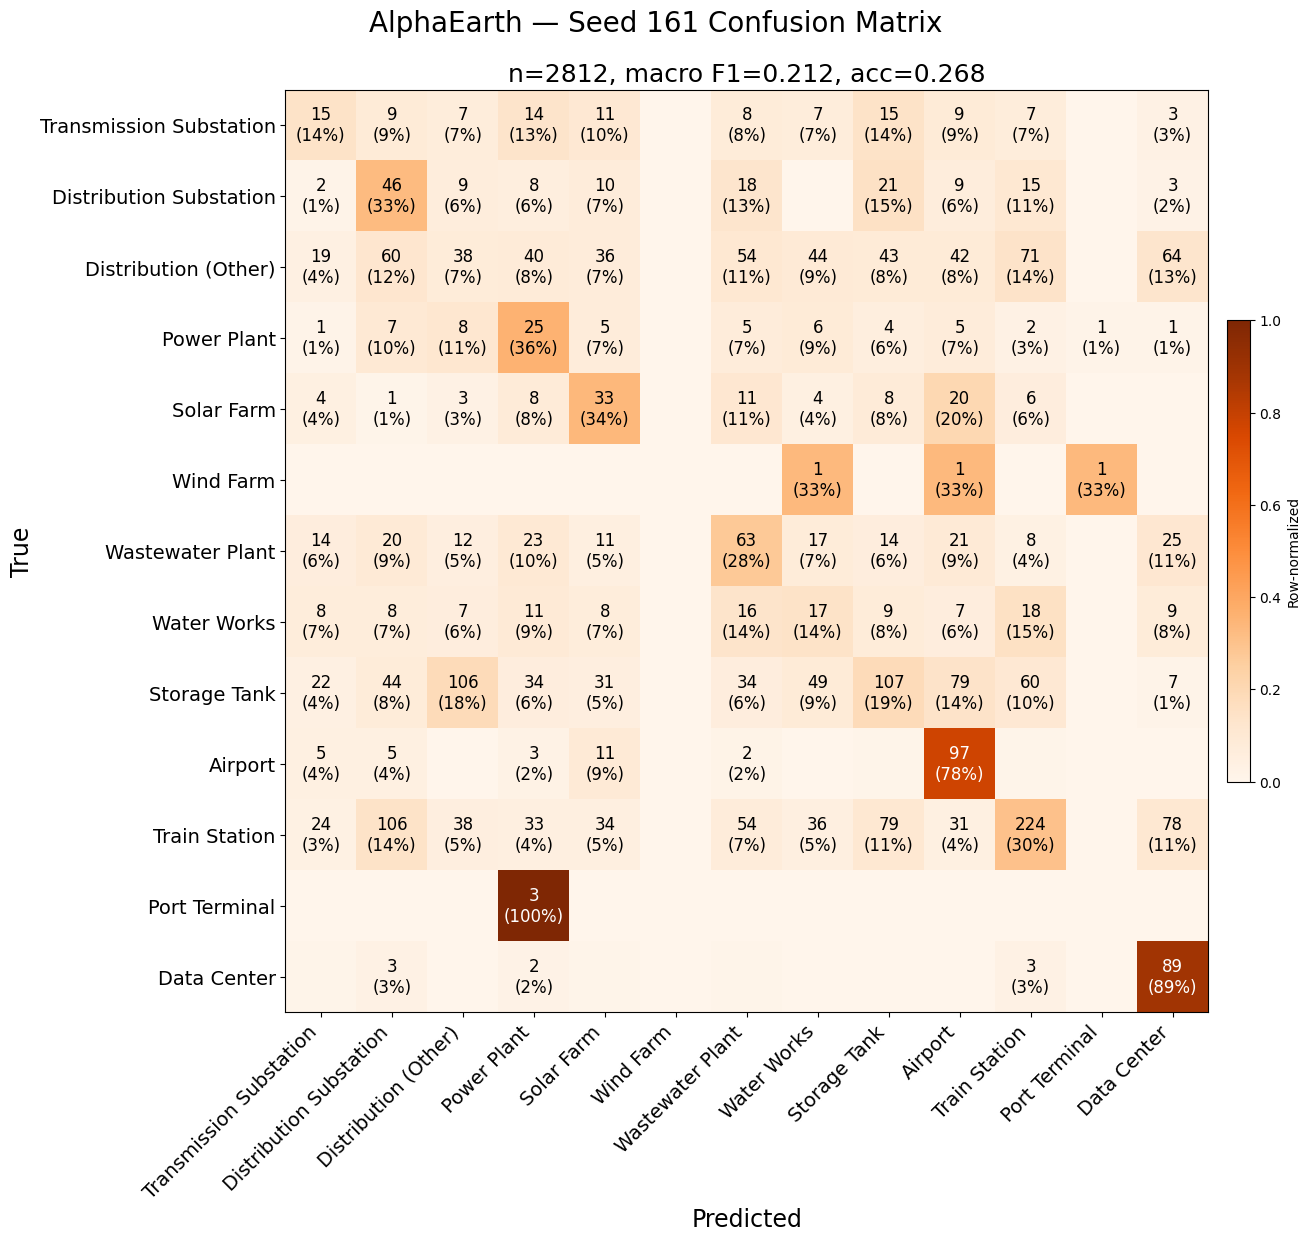


AlphaEarth v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.1500      0.1475      0.1364      0.1446 ± 0.0059
[ 1] energy.distribution.substation     0.2039      0.2092      0.2044      0.2058 ± 0.0024
[ 2] energy.distribution.other          0.1058      0.1034      0.1028      0.1040 ± 0.0013
[ 3] energy.generation.power_plant      0.1860      0.1812      0.1825      0.1832 ± 0.0021
[ 4] energy.generation.solar_farm       0.2290      0.2416      0.2284      0.2330 ± 0.0061
[ 5] energy.generation.wind_farm        0.0000      0.0000      0.0000      0.0000 ± 0.0000
[ 6] water.wastewater.plant             0.2685      0.2531      0.2551      0.2589 ± 0.0068
[ 7] water.water_works                  0.1168      0.1119      0.1137      0.1141 ± 0.0020
[ 8] water.storage_tank 

{314: {'cm': array([[ 18,   7,   8,  12,  13,   0,   8,   7,  14,   9,   6,   0,   3],
         [  2,  47,   8,   8,  10,   0,  20,   0,  19,   9,  15,   0,   3],
         [ 23,  63,  40,  38,  36,   0,  58,  35,  44,  40,  70,   0,  64],
         [  1,   7,   8,  24,   5,   0,   7,   5,   4,   5,   2,   1,   1],
         [  6,   1,   2,   6,  34,   0,  11,   4,   8,  20,   6,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   0,   1,   0],
         [ 17,  20,  11,  21,  12,   0,  69,  14,  11,  20,   8,   0,  25],
         [  8,   8,   8,  12,   8,   0,  17,  16,   8,   7,  17,   0,   9],
         [ 26,  46, 114,  30,  32,   0,  37,  44, 109,  76,  52,   0,   7],
         [  5,   5,   0,   3,  13,   0,   2,   0,   1,  94,   1,   0,   1],
         [ 28, 111,  45,  30,  35,   0,  56,  31,  77,  31, 217,   0,  76],
         [  0,   0,   0,   3,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  1,   5,   1,   1,   1,   0,   1,   0,   0,   0,   3,   0,  87]]),

In [12]:
confusion_matrix('alphaearth', cmap="Oranges")

## Prithvi

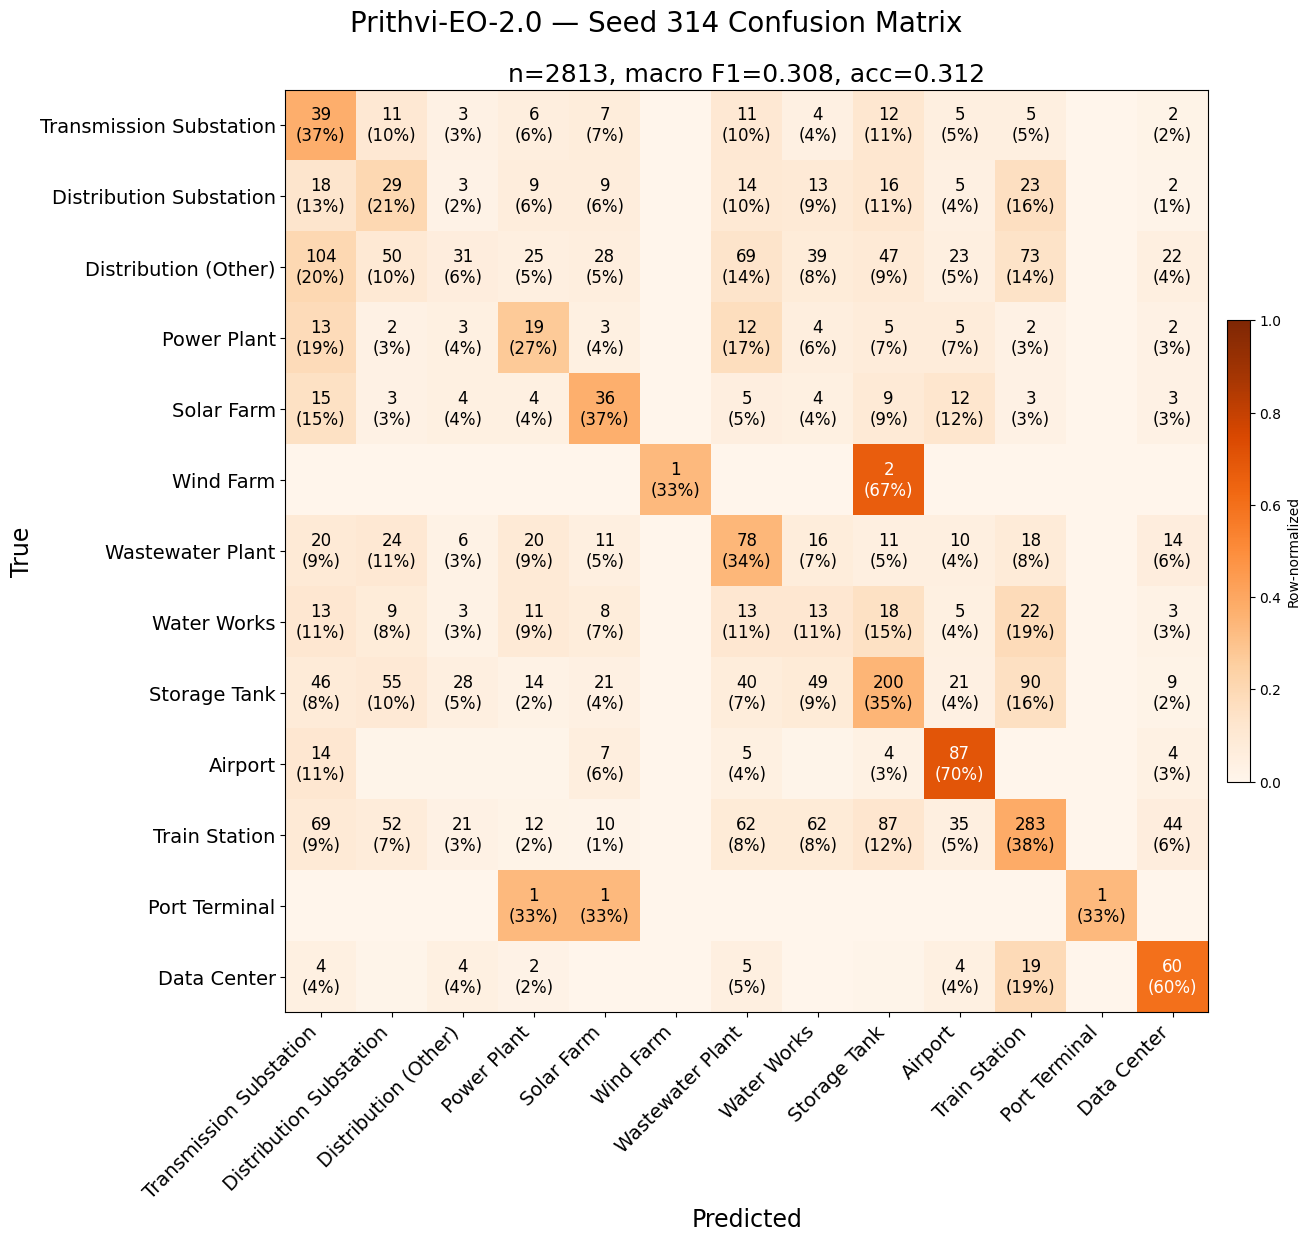

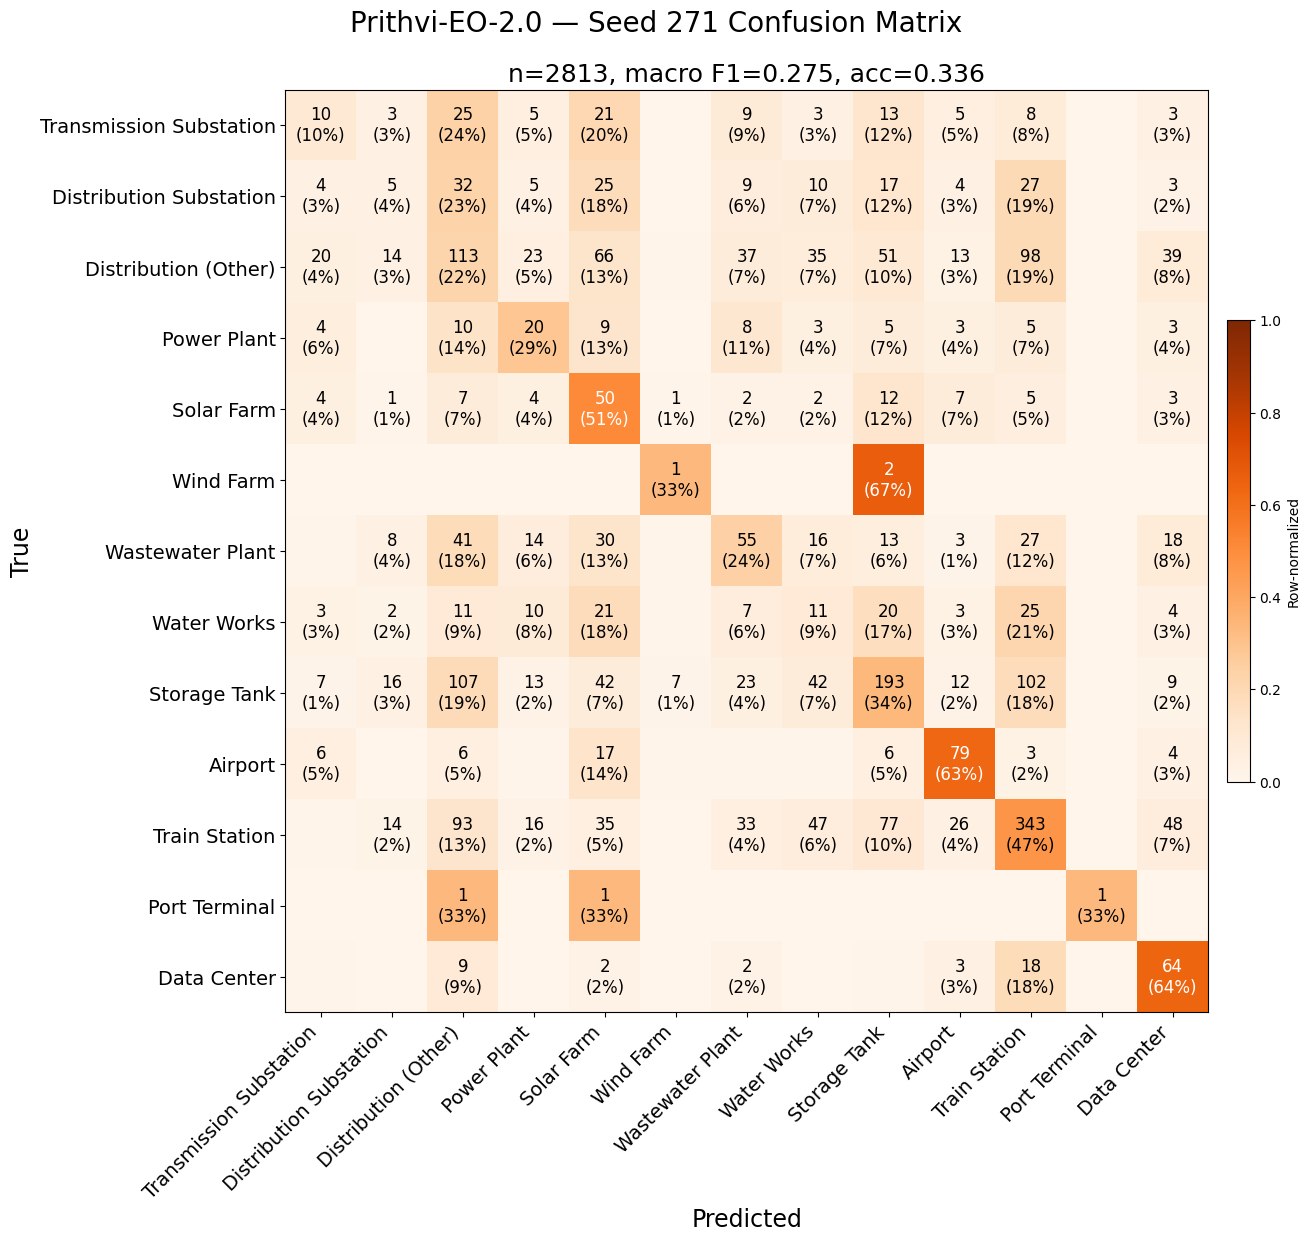

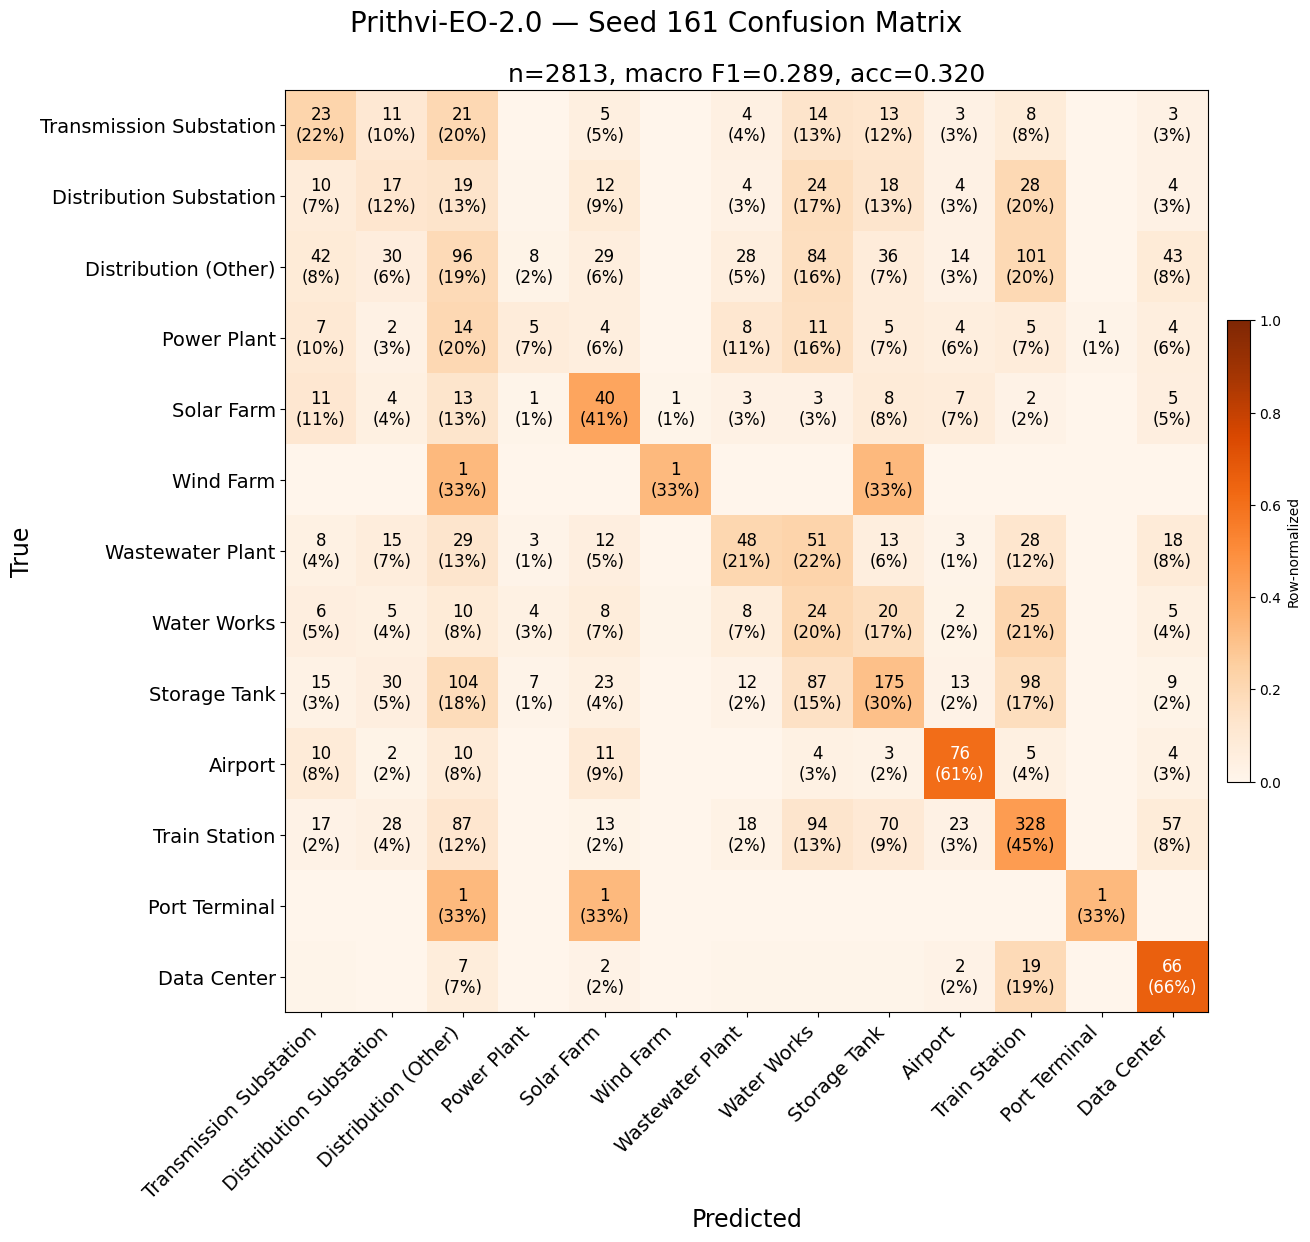


Prithvi-EO-2.0 v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.1696      0.1183      0.1804      0.1561 ± 0.0271
[ 1] energy.distribution.substation     0.1534      0.0490      0.1193      0.1073 ± 0.0435
[ 2] energy.distribution.other          0.1003      0.2340      0.2080      0.1808 ± 0.0579
[ 3] energy.generation.power_plant      0.1959      0.2210      0.0990      0.1720 ± 0.0526
[ 4] energy.generation.solar_farm       0.3013      0.2398      0.3101      0.2837 ± 0.0313
[ 5] energy.generation.wind_farm        0.5000      0.1053      0.3333      0.3129 ± 0.1618
[ 6] water.wastewater.plant             0.2878      0.2657      0.2652      0.2729 ± 0.0106
[ 7] water.water_works                  0.0805      0.0764      0.0932      0.0834 ± 0.0072
[ 8] water.storage_t

{314: {'cm': array([[ 39,  11,   3,   6,   7,   0,  11,   4,  12,   5,   5,   0,   2],
         [ 18,  29,   3,   9,   9,   0,  14,  13,  16,   5,  23,   0,   2],
         [104,  50,  31,  25,  28,   0,  69,  39,  47,  23,  73,   0,  22],
         [ 13,   2,   3,  19,   3,   0,  12,   4,   5,   5,   2,   0,   2],
         [ 15,   3,   4,   4,  36,   0,   5,   4,   9,  12,   3,   0,   3],
         [  0,   0,   0,   0,   0,   1,   0,   0,   2,   0,   0,   0,   0],
         [ 20,  24,   6,  20,  11,   0,  78,  16,  11,  10,  18,   0,  14],
         [ 13,   9,   3,  11,   8,   0,  13,  13,  18,   5,  22,   0,   3],
         [ 46,  55,  28,  14,  21,   0,  40,  49, 200,  21,  90,   1,   9],
         [ 14,   1,   1,   1,   7,   0,   5,   1,   4,  87,   0,   0,   4],
         [ 69,  52,  21,  12,  10,   0,  62,  62,  87,  35, 283,   0,  44],
         [  0,   0,   0,   1,   1,   0,   0,   0,   0,   0,   0,   1,   0],
         [  4,   1,   4,   2,   0,   0,   5,   0,   1,   4,  19,   0,  60]]),

In [13]:
confusion_matrix('prithvi', cmap="Oranges")

## ResNet

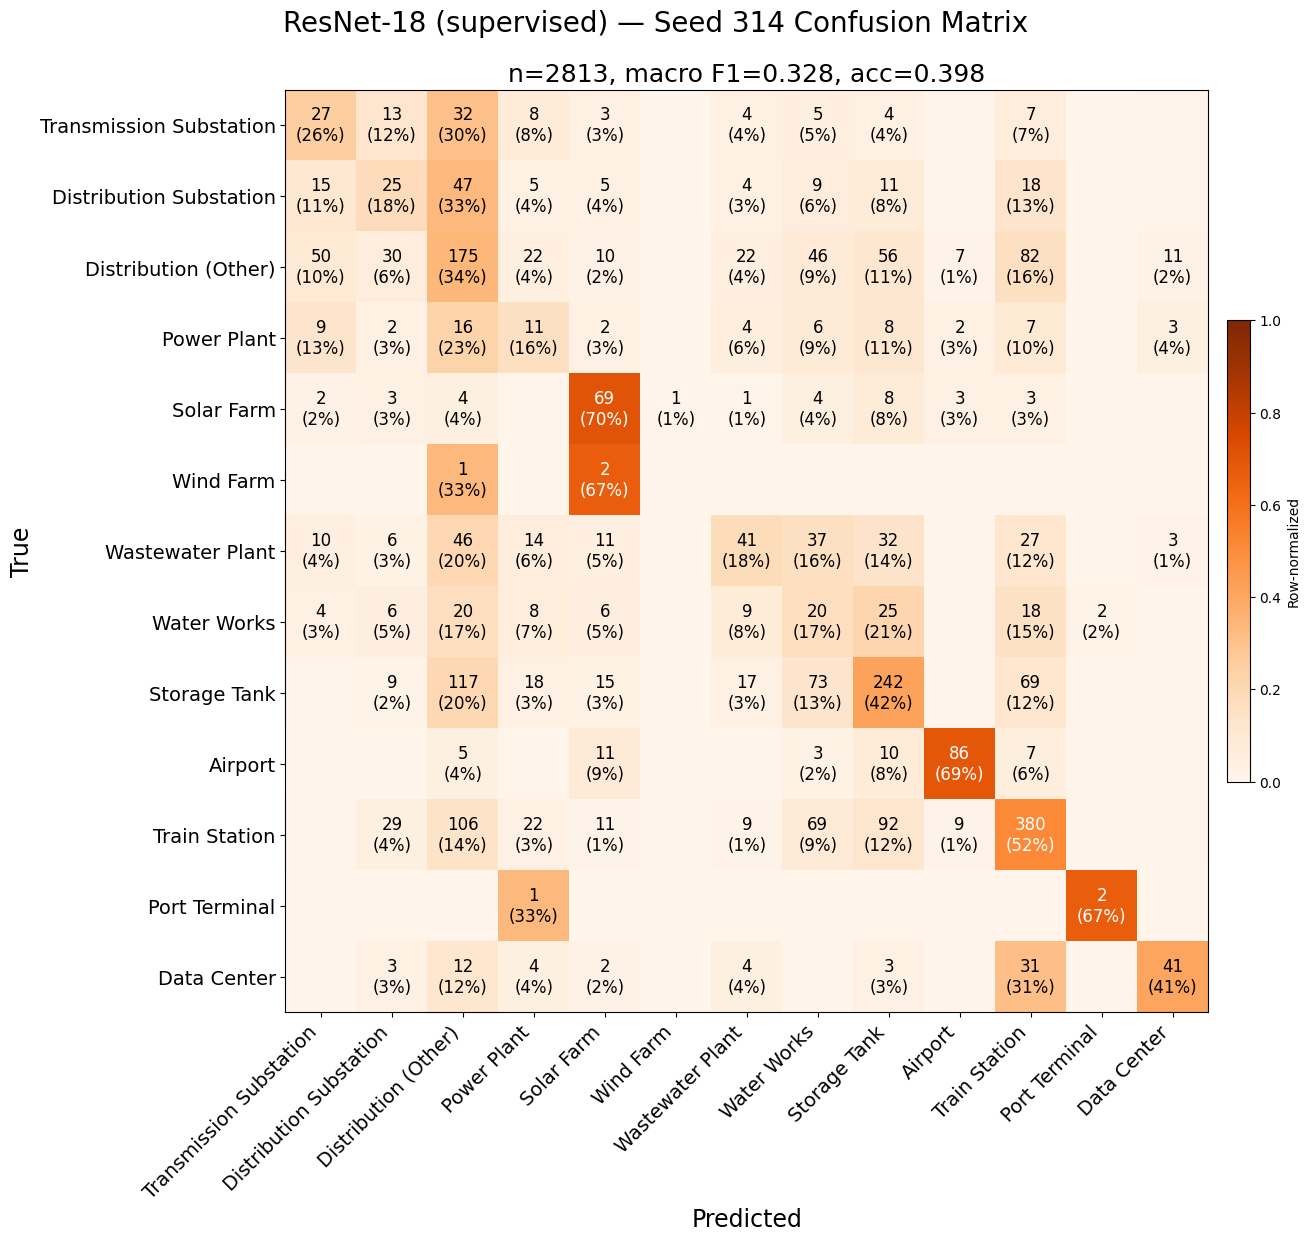

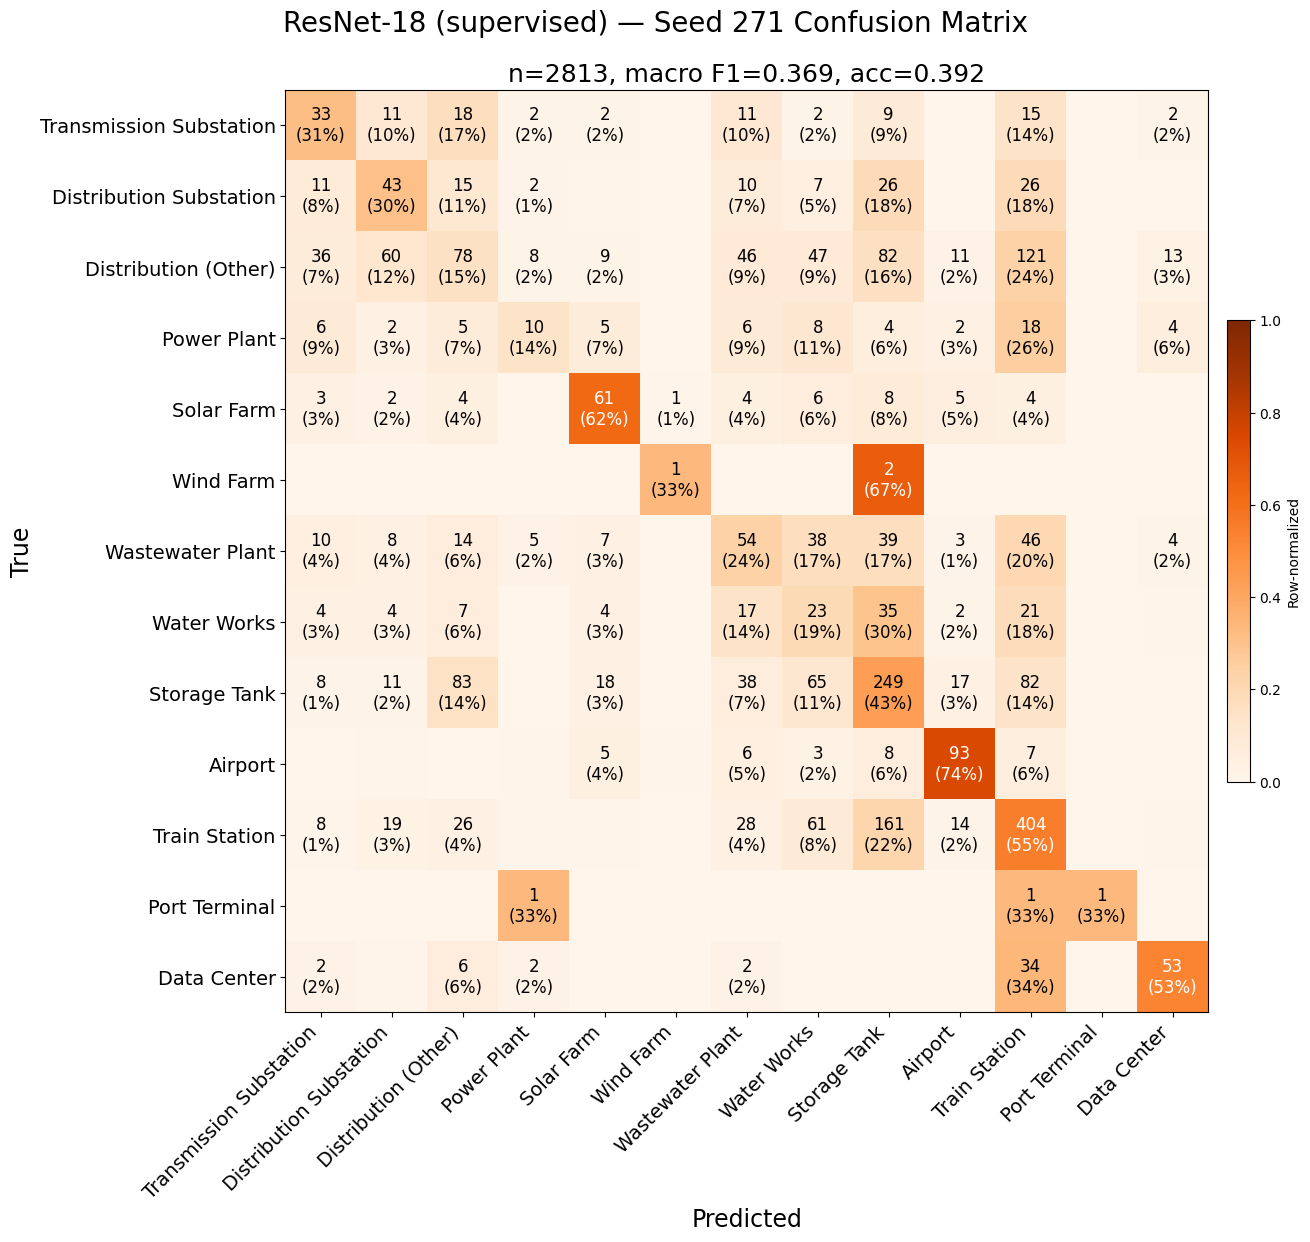

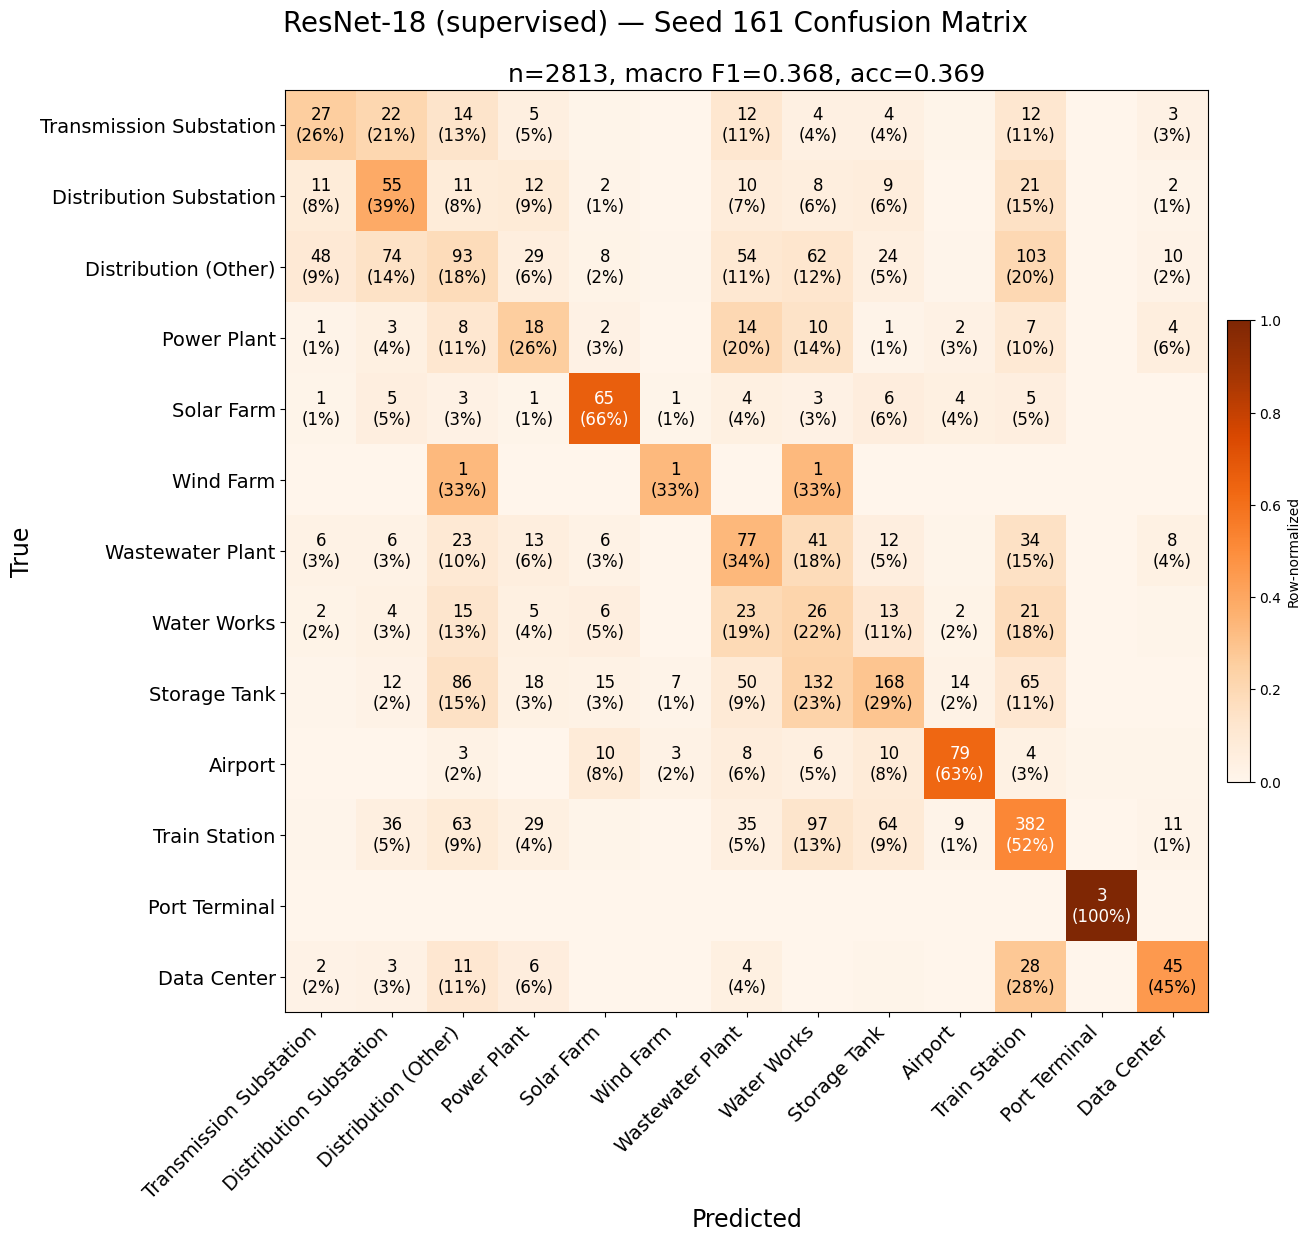


ResNet-18 (supervised) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.2358      0.2920      0.2571      0.2617 ± 0.0232
[ 1] energy.distribution.substation     0.1873      0.2838      0.3047      0.2586 ± 0.0512
[ 2] energy.distribution.other          0.3205      0.2034      0.2209      0.2483 ± 0.0516
[ 3] energy.generation.power_plant      0.1196      0.1887      0.1748      0.1610 ± 0.0298
[ 4] energy.generation.solar_farm       0.5633      0.5648      0.5909      0.5730 ± 0.0127
[ 5] energy.generation.wind_farm        0.0000      0.2857      0.1111      0.1323 ± 0.1176
[ 6] water.wastewater.plant             0.2384      0.2400      0.2967      0.2584 ± 0.0271
[ 7] water.water_works                  0.1026      0.1217      0.1024      0.1089 ± 0.0091
[ 8] water.s

{314: {'cm': array([[ 27,  13,  32,   8,   3,   0,   4,   5,   4,   1,   7,   0,   1],
         [ 15,  25,  47,   5,   5,   0,   4,   9,  11,   1,  18,   0,   1],
         [ 50,  30, 175,  22,  10,   0,  22,  46,  56,   7,  82,   0,  11],
         [  9,   2,  16,  11,   2,   0,   4,   6,   8,   2,   7,   0,   3],
         [  2,   3,   4,   0,  69,   1,   1,   4,   8,   3,   3,   0,   0],
         [  0,   0,   1,   0,   2,   0,   0,   0,   0,   0,   0,   0,   0],
         [ 10,   6,  46,  14,  11,   0,  41,  37,  32,   0,  27,   1,   3],
         [  4,   6,  20,   8,   6,   0,   9,  20,  25,   0,  18,   2,   0],
         [  4,   9, 117,  18,  15,   1,  17,  73, 242,   5,  69,   2,   2],
         [  0,   0,   5,   1,  11,   0,   1,   3,  10,  86,   7,   1,   0],
         [  3,  29, 106,  22,  11,   0,   9,  69,  92,   9, 380,   3,   4],
         [  0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   2,   0],
         [  0,   3,  12,   4,   2,   0,   4,   0,   3,   0,  31,   0,  41]]),

In [14]:
confusion_matrix('resnet', cmap='Oranges')

## Aggregate Confusion Matrices (main paper figures)

One figure per FM: raw counts summed across all three seeds, then row-normalized.

### Satlas S1

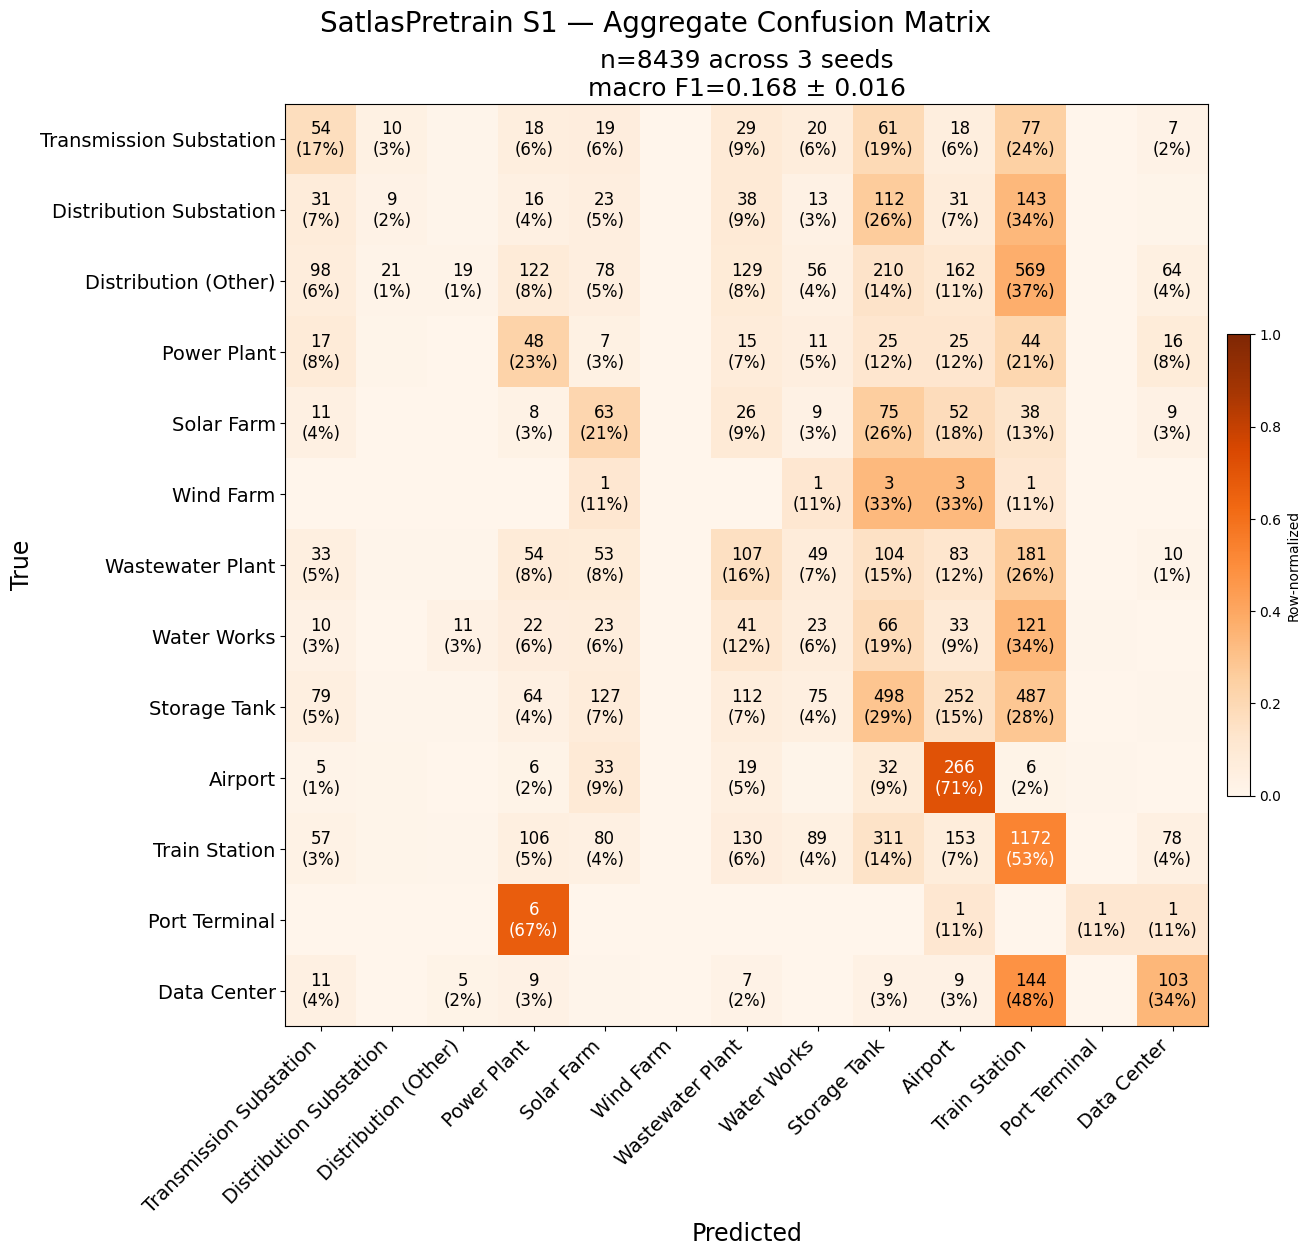


SatlasPretrain S1 v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.1333      0.1538      0.1552      0.1475 ± 0.0100
[ 1] energy.distribution.substation     0.0000      0.0841      0.0000      0.0280 ± 0.0397
[ 2] energy.distribution.other          0.0264      0.0000      0.0429      0.0231 ± 0.0177
[ 3] energy.generation.power_plant      0.1436      0.1277      0.1441      0.1385 ± 0.0076
[ 4] energy.generation.solar_farm       0.1802      0.1303      0.1679      0.1595 ± 0.0212
[ 5] energy.generation.wind_farm        0.0000      0.0000      0.0000      0.0000 ± 0.0000
[ 6] water.wastewater.plant             0.2033      0.0000      0.1807      0.1280 ± 0.0910
[ 7] water.water_works                  0.0000      0.1004      0.0000      0.0335 ± 0.0473
[ 8] water.storag

{314: {'cm': array([[ 11,   0,   0,  13,   6,   0,  19,   0,  36,   1,  19,   0,   0],
         [  3,   0,   2,  10,   4,   0,  19,   0,  56,   0,  47,   0,   0],
         [ 15,   0,   7,  83,  18,   0,  74,   1, 117,  11, 175,   0,  10],
         [  2,   0,   0,  28,   2,   0,   7,   1,  13,   1,  13,   0,   3],
         [  3,   0,   0,   6,  20,   0,  13,   0,  37,   5,  13,   0,   1],
         [  0,   0,   0,   0,   0,   0,   0,   0,   2,   1,   0,   0,   0],
         [  3,   0,   3,  34,  12,   0,  62,   1,  56,   7,  49,   0,   1],
         [  1,   0,   4,  13,   5,   0,  23,   0,  35,   2,  34,   1,   0],
         [ 14,   0,   2,  40,  32,   0,  69,   1, 246,  37, 133,   0,   0],
         [  0,   0,   0,   6,  16,   0,  10,   0,  21,  71,   1,   0,   0],
         [  6,   1,   2,  75,   9,   0,  83,   0, 165,  10, 376,   0,  10],
         [  0,   0,   0,   3,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  2,   0,   0,   9,   0,   0,   3,   0,   7,   0,  56,   0,  23]]),

In [15]:
confusion_matrix_aggregate('satlas_s1', cmap='Oranges')

### Satlas S2

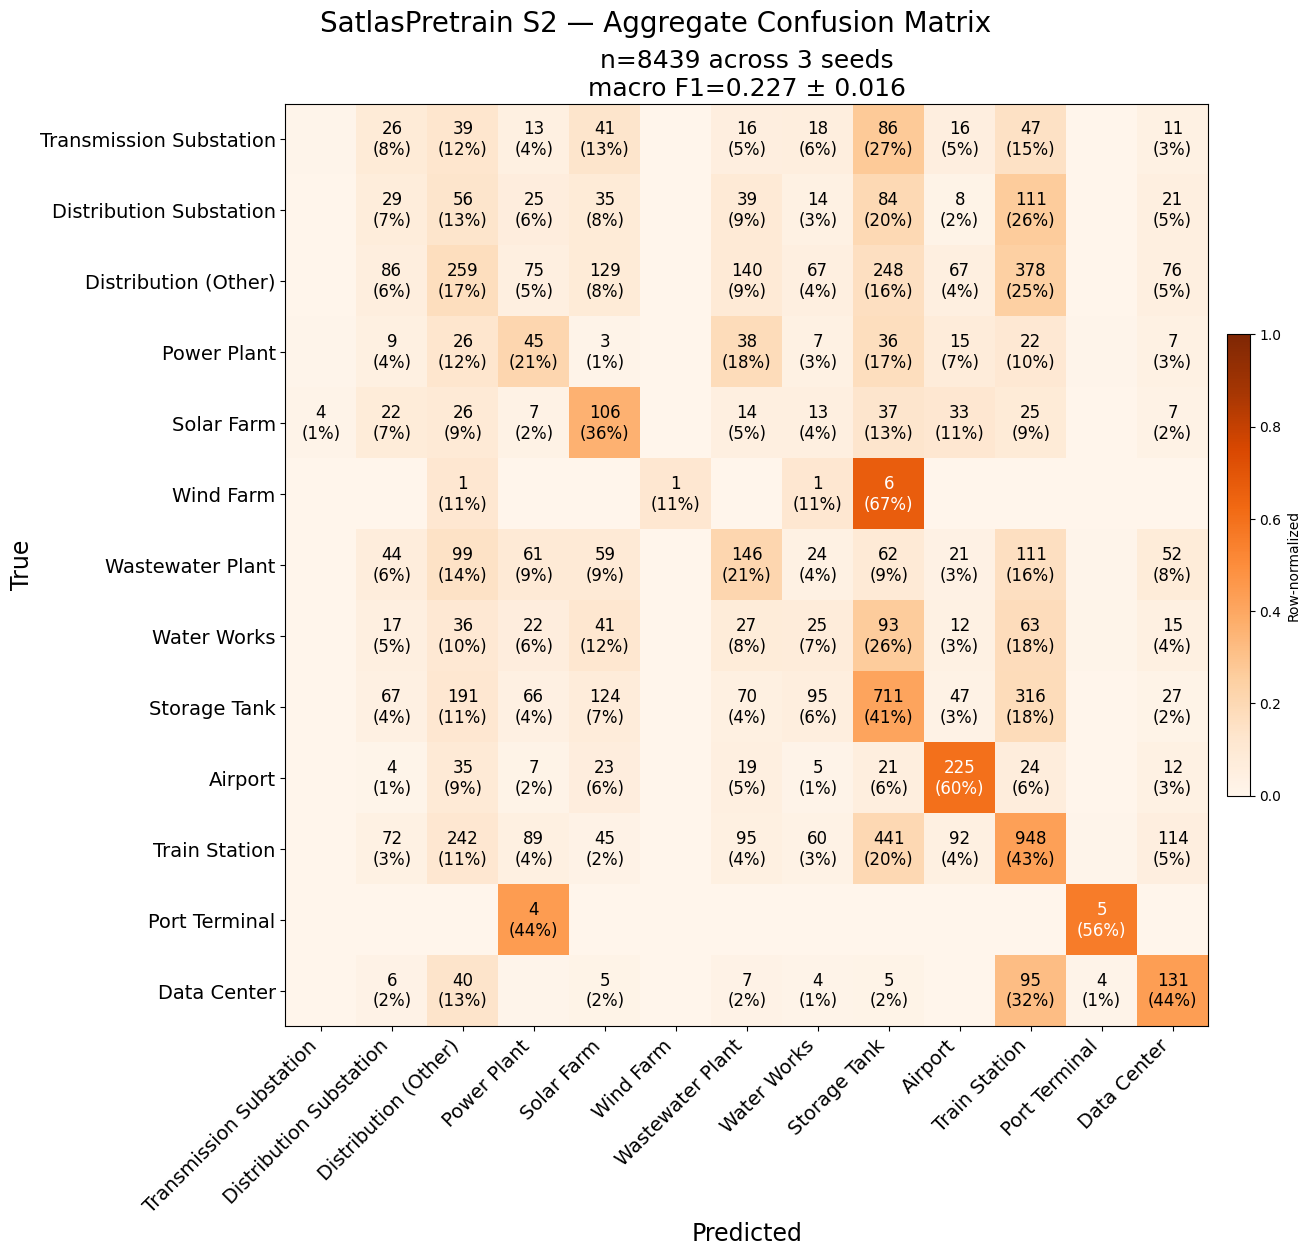


SatlasPretrain S2 v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.0323      0.0000      0.0000      0.0108 ± 0.0152
[ 1] energy.distribution.substation     0.0000      0.0123      0.1116      0.0413 ± 0.0499
[ 2] energy.distribution.other          0.0394      0.1988      0.2754      0.1712 ± 0.0983
[ 3] energy.generation.power_plant      0.1733      0.0000      0.1527      0.1087 ± 0.0773
[ 4] energy.generation.solar_farm       0.2111      0.2436      0.2617      0.2388 ± 0.0209
[ 5] energy.generation.wind_farm        0.5000      0.0000      0.0000      0.1667 ± 0.2357
[ 6] water.wastewater.plant             0.2418      0.2657      0.0996      0.2023 ± 0.0733
[ 7] water.water_works                  0.0000      0.1040      0.0494      0.0511 ± 0.0425
[ 8] water.storag

{314: {'cm': array([[  2,   0,   2,   7,  18,   0,   1,   0,  39,   9,  23,   0,   4],
         [  0,   0,   1,  12,  16,   0,   9,   0,  35,   5,  54,   0,   9],
         [  5,   0,  11,  37,  60,   0,  38,   0, 119,  32, 188,   0,  21],
         [  1,   0,   3,  24,   2,   0,   7,   0,  15,   7,  10,   0,   1],
         [  4,   0,   1,   3,  40,   0,   3,   0,  17,  14,  14,   0,   2],
         [  0,   0,   0,   0,   0,   1,   0,   0,   2,   0,   0,   0,   0],
         [  2,   0,   9,  28,  32,   0,  44,   0,  30,  11,  57,   0,  15],
         [  0,   0,   2,  11,  19,   0,   4,   0,  37,   8,  32,   0,   5],
         [  2,   0,   5,  34,  56,   0,  11,   3, 267,  23, 164,   1,   8],
         [  0,   0,   4,   2,  10,   0,   3,   0,   6,  87,   8,   0,   5],
         [  3,   0,   7,  46,  24,   0,  16,   0, 170,  38, 400,   1,  32],
         [  0,   0,   0,   2,   0,   0,   0,   0,   0,   0,   0,   1,   0],
         [  0,   0,   2,   1,   4,   0,   0,   0,   4,   1,  47,   0,  41]]),

In [16]:
confusion_matrix_aggregate('satlas_s2', cmap='Oranges')

### CROMA

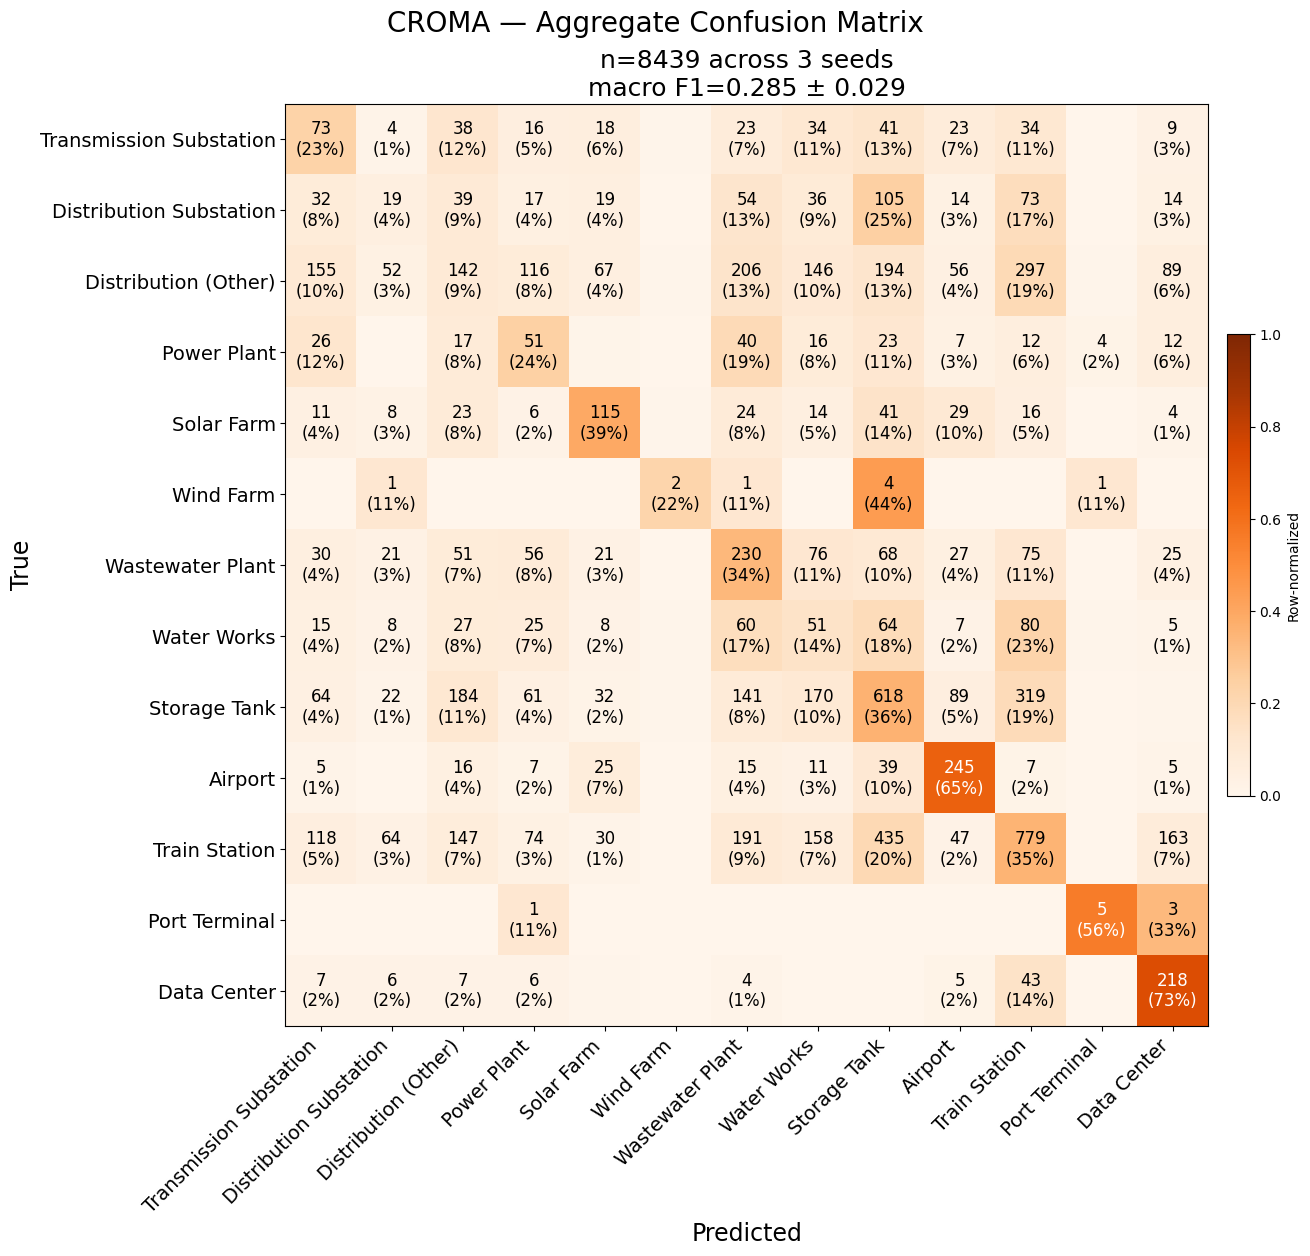


CROMA v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.1976      0.0781      0.1674      0.1477 ± 0.0507
[ 1] energy.distribution.substation     0.0915      0.0380      0.0141      0.0478 ± 0.0324
[ 2] energy.distribution.other          0.0994      0.1740      0.1079      0.1271 ± 0.0334
[ 3] energy.generation.power_plant      0.1687      0.1345      0.1452      0.1494 ± 0.0143
[ 4] energy.generation.solar_farm       0.3696      0.3786      0.3398      0.3627 ± 0.0166
[ 5] energy.generation.wind_farm        0.5000      0.5000      0.0000      0.3333 ± 0.2357
[ 6] water.wastewater.plant             0.2448      0.2880      0.2801      0.2709 ± 0.0188
[ 7] water.water_works                  0.0923      0.1101      0.0609      0.0878 ± 0.0203
[ 8] water.storage_tank      

{314: {'cm': array([[ 49,   4,   9,  11,   3,   0,   2,   7,  13,   3,   3,   0,   1],
         [ 26,  15,  12,  13,   4,   0,   8,   9,  39,   3,   8,   0,   4],
         [101,  44,  40,  84,  16,   0,  36,  44,  68,  11,  45,   0,  22],
         [ 12,   0,   3,  34,   1,   0,   4,   2,   9,   2,   1,   0,   2],
         [  9,   7,  10,   6,  34,   0,   6,   2,  16,   7,   1,   0,   0],
         [  0,   1,   0,   0,   0,   1,   0,   0,   1,   0,   0,   0,   0],
         [ 27,  21,  13,  46,   7,   0,  47,  20,  27,   7,   6,   0,   7],
         [ 13,   7,   9,  19,   1,   0,  10,  15,  28,   1,  14,   0,   1],
         [ 50,  21, 110,  45,   8,   0,  19,  46, 226,  24,  22,   0,   3],
         [  5,   0,   6,   7,   6,   0,   2,   3,  13,  80,   1,   0,   2],
         [ 95,  62,  79,  61,   5,   0,  22,  59, 167,   7, 127,   0,  53],
         [  0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   1,   1],
         [  4,   5,   3,   6,   1,   0,   0,   0,   0,   1,   9,   0,  71]]),

In [17]:
confusion_matrix_aggregate('croma', cmap='Oranges')

### AlphaEarth

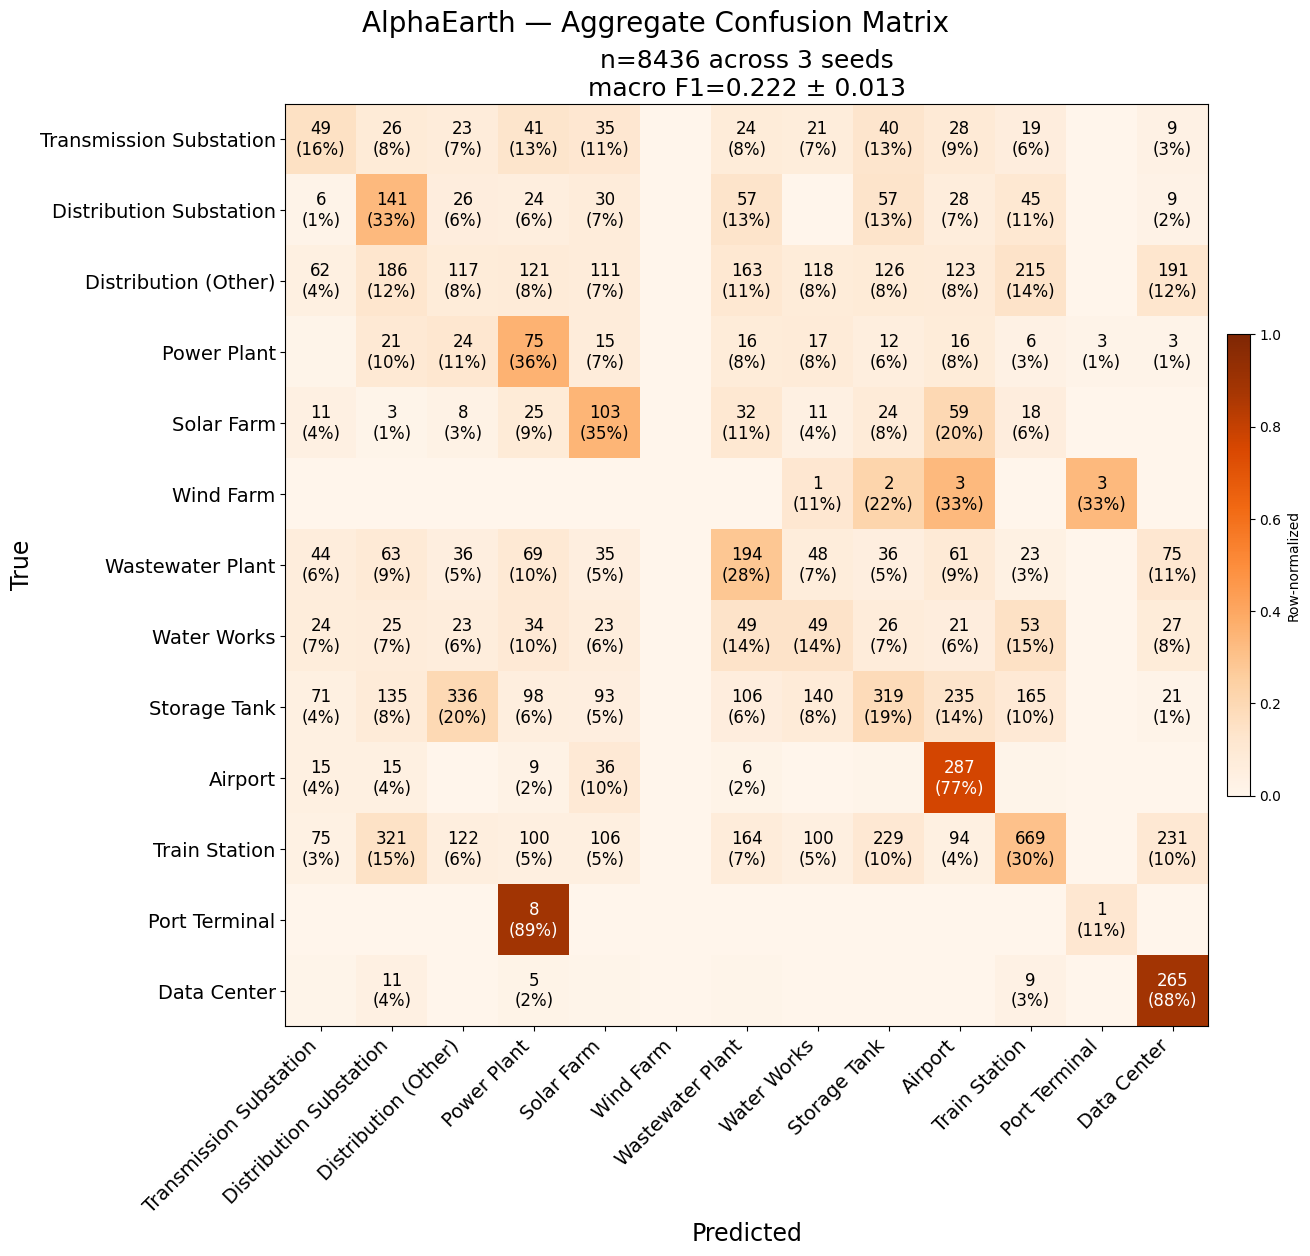


AlphaEarth v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.1500      0.1475      0.1364      0.1446 ± 0.0059
[ 1] energy.distribution.substation     0.2039      0.2092      0.2044      0.2058 ± 0.0024
[ 2] energy.distribution.other          0.1058      0.1034      0.1028      0.1040 ± 0.0013
[ 3] energy.generation.power_plant      0.1860      0.1812      0.1825      0.1832 ± 0.0021
[ 4] energy.generation.solar_farm       0.2290      0.2416      0.2284      0.2330 ± 0.0061
[ 5] energy.generation.wind_farm        0.0000      0.0000      0.0000      0.0000 ± 0.0000
[ 6] water.wastewater.plant             0.2685      0.2531      0.2551      0.2589 ± 0.0068
[ 7] water.water_works                  0.1168      0.1119      0.1137      0.1141 ± 0.0020
[ 8] water.storage_tank 

{314: {'cm': array([[ 18,   7,   8,  12,  13,   0,   8,   7,  14,   9,   6,   0,   3],
         [  2,  47,   8,   8,  10,   0,  20,   0,  19,   9,  15,   0,   3],
         [ 23,  63,  40,  38,  36,   0,  58,  35,  44,  40,  70,   0,  64],
         [  1,   7,   8,  24,   5,   0,   7,   5,   4,   5,   2,   1,   1],
         [  6,   1,   2,   6,  34,   0,  11,   4,   8,  20,   6,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   0,   1,   0],
         [ 17,  20,  11,  21,  12,   0,  69,  14,  11,  20,   8,   0,  25],
         [  8,   8,   8,  12,   8,   0,  17,  16,   8,   7,  17,   0,   9],
         [ 26,  46, 114,  30,  32,   0,  37,  44, 109,  76,  52,   0,   7],
         [  5,   5,   0,   3,  13,   0,   2,   0,   1,  94,   1,   0,   1],
         [ 28, 111,  45,  30,  35,   0,  56,  31,  77,  31, 217,   0,  76],
         [  0,   0,   0,   3,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  1,   5,   1,   1,   1,   0,   1,   0,   0,   0,   3,   0,  87]]),

In [18]:
confusion_matrix_aggregate('alphaearth', cmap='Oranges')

### Prithvi

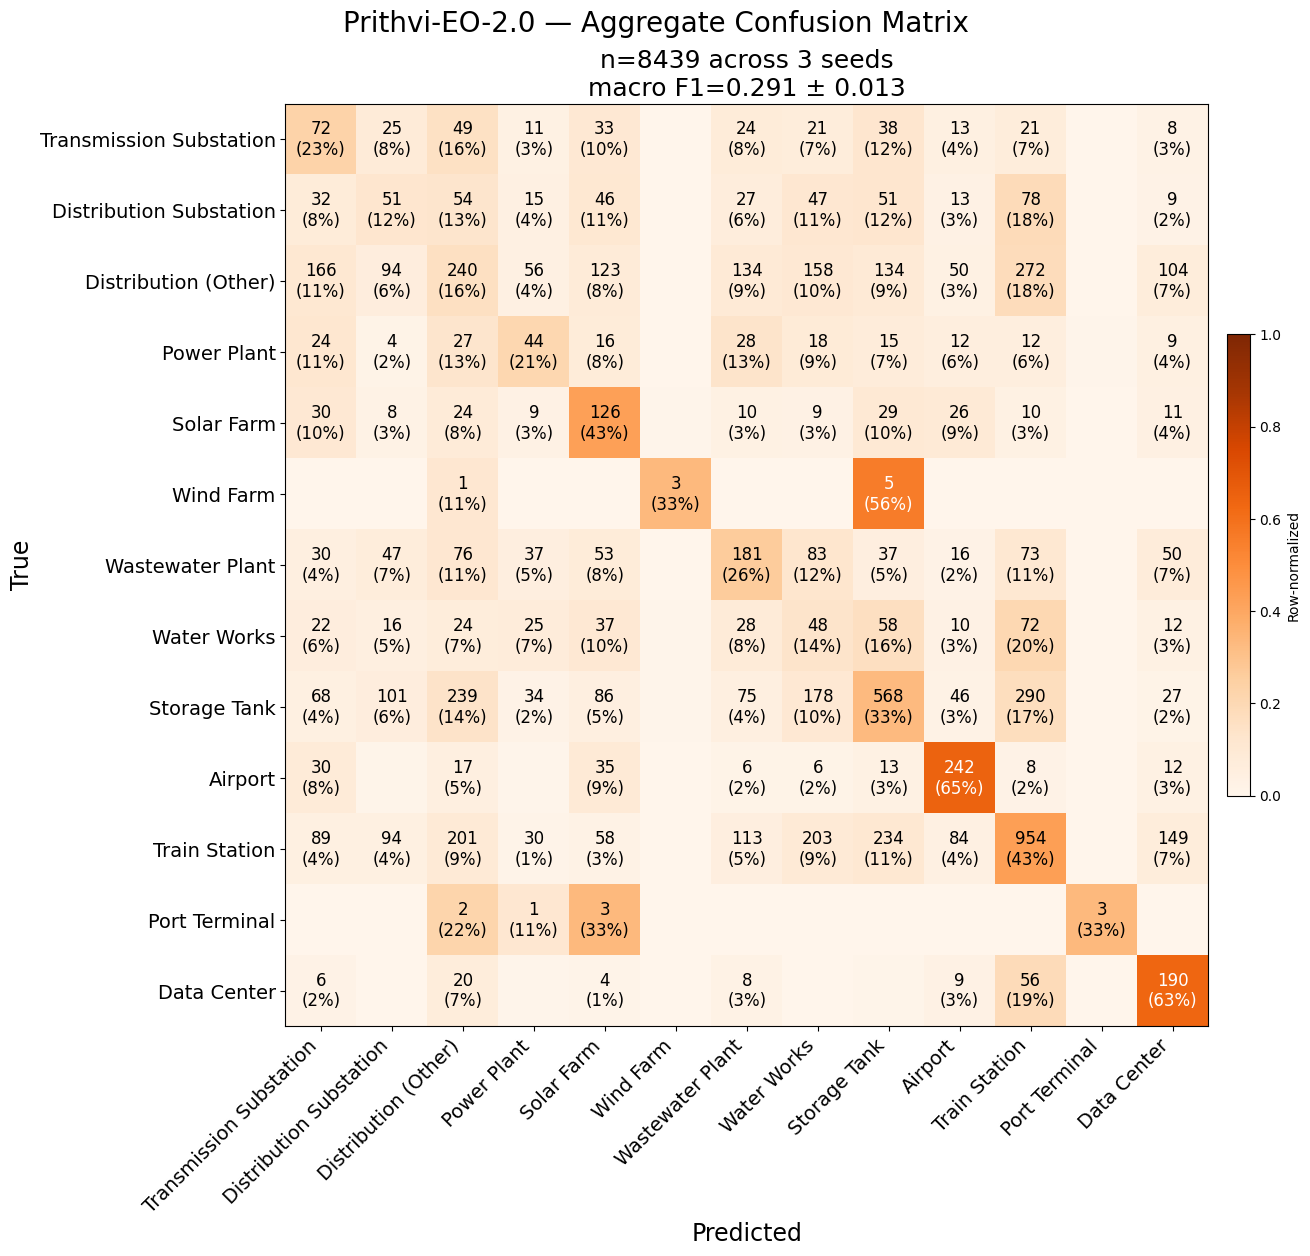


Prithvi-EO-2.0 v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.1696      0.1183      0.1804      0.1561 ± 0.0271
[ 1] energy.distribution.substation     0.1534      0.0490      0.1193      0.1073 ± 0.0435
[ 2] energy.distribution.other          0.1003      0.2340      0.2080      0.1808 ± 0.0579
[ 3] energy.generation.power_plant      0.1959      0.2210      0.0990      0.1720 ± 0.0526
[ 4] energy.generation.solar_farm       0.3013      0.2398      0.3101      0.2837 ± 0.0313
[ 5] energy.generation.wind_farm        0.5000      0.1053      0.3333      0.3129 ± 0.1618
[ 6] water.wastewater.plant             0.2878      0.2657      0.2652      0.2729 ± 0.0106
[ 7] water.water_works                  0.0805      0.0764      0.0932      0.0834 ± 0.0072
[ 8] water.storage_t

{314: {'cm': array([[ 39,  11,   3,   6,   7,   0,  11,   4,  12,   5,   5,   0,   2],
         [ 18,  29,   3,   9,   9,   0,  14,  13,  16,   5,  23,   0,   2],
         [104,  50,  31,  25,  28,   0,  69,  39,  47,  23,  73,   0,  22],
         [ 13,   2,   3,  19,   3,   0,  12,   4,   5,   5,   2,   0,   2],
         [ 15,   3,   4,   4,  36,   0,   5,   4,   9,  12,   3,   0,   3],
         [  0,   0,   0,   0,   0,   1,   0,   0,   2,   0,   0,   0,   0],
         [ 20,  24,   6,  20,  11,   0,  78,  16,  11,  10,  18,   0,  14],
         [ 13,   9,   3,  11,   8,   0,  13,  13,  18,   5,  22,   0,   3],
         [ 46,  55,  28,  14,  21,   0,  40,  49, 200,  21,  90,   1,   9],
         [ 14,   1,   1,   1,   7,   0,   5,   1,   4,  87,   0,   0,   4],
         [ 69,  52,  21,  12,  10,   0,  62,  62,  87,  35, 283,   0,  44],
         [  0,   0,   0,   1,   1,   0,   0,   0,   0,   0,   0,   1,   0],
         [  4,   1,   4,   2,   0,   0,   5,   0,   1,   4,  19,   0,  60]]),

In [19]:
confusion_matrix_aggregate('prithvi', cmap='Oranges')

## ResNet-18

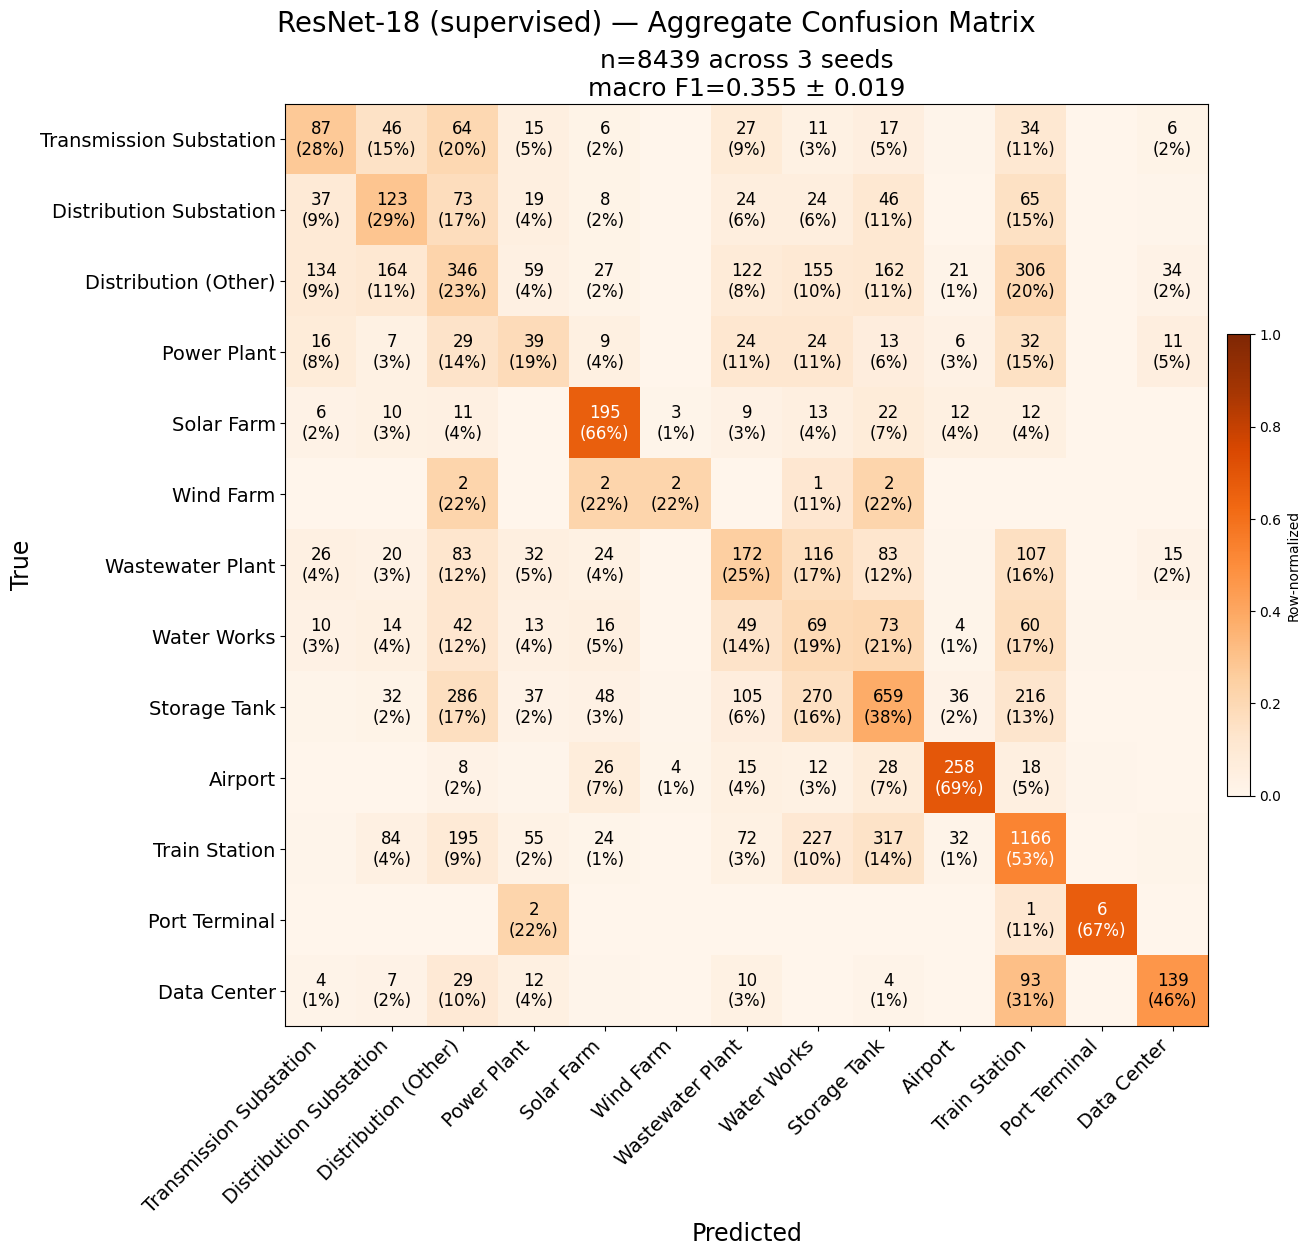


ResNet-18 (supervised) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.2358      0.2920      0.2571      0.2617 ± 0.0232
[ 1] energy.distribution.substation     0.1873      0.2838      0.3047      0.2586 ± 0.0512
[ 2] energy.distribution.other          0.3205      0.2034      0.2209      0.2483 ± 0.0516
[ 3] energy.generation.power_plant      0.1196      0.1887      0.1748      0.1610 ± 0.0298
[ 4] energy.generation.solar_farm       0.5633      0.5648      0.5909      0.5730 ± 0.0127
[ 5] energy.generation.wind_farm        0.0000      0.2857      0.1111      0.1323 ± 0.1176
[ 6] water.wastewater.plant             0.2384      0.2400      0.2967      0.2584 ± 0.0271
[ 7] water.water_works                  0.1026      0.1217      0.1024      0.1089 ± 0.0091
[ 8] water.s

{314: {'cm': array([[ 27,  13,  32,   8,   3,   0,   4,   5,   4,   1,   7,   0,   1],
         [ 15,  25,  47,   5,   5,   0,   4,   9,  11,   1,  18,   0,   1],
         [ 50,  30, 175,  22,  10,   0,  22,  46,  56,   7,  82,   0,  11],
         [  9,   2,  16,  11,   2,   0,   4,   6,   8,   2,   7,   0,   3],
         [  2,   3,   4,   0,  69,   1,   1,   4,   8,   3,   3,   0,   0],
         [  0,   0,   1,   0,   2,   0,   0,   0,   0,   0,   0,   0,   0],
         [ 10,   6,  46,  14,  11,   0,  41,  37,  32,   0,  27,   1,   3],
         [  4,   6,  20,   8,   6,   0,   9,  20,  25,   0,  18,   2,   0],
         [  4,   9, 117,  18,  15,   1,  17,  73, 242,   5,  69,   2,   2],
         [  0,   0,   5,   1,  11,   0,   1,   3,  10,  86,   7,   1,   0],
         [  3,  29, 106,  22,  11,   0,   9,  69,  92,   9, 380,   3,   4],
         [  0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   2,   0],
         [  0,   3,  12,   4,   2,   0,   4,   0,   3,   0,  31,   0,  41]]),

In [20]:
confusion_matrix_aggregate('resnet', cmap='Oranges')

# Save all figures to disk (Task 3)

Regenerates and writes all 24 confusion matrix PNGs (6 aggregate + 18 per-seed) to each FM's results directory in Drive. Uses the updated `'Water Works'` display name and `'Oranges'` colormap. Filenames:

- `confusion_matrix_{file_prefix}_aggregate.png` — main-paper figures
- `confusion_matrix_{file_prefix}_seed{seed}.png` — appendix per-seed figures

Overwrites any existing PNGs at those paths (which is intentional — the old ones have the stale `'Treatment Plant'` label).

In [21]:
# Run once. Writes 24 PNGs to Drive under /content/drive/MyDrive/infra_fm/results/.
# Prints the path of each file it writes.
written = save_all_confusion_matrices()

  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_croma_v2_spatial/confusion_matrix_croma_v2_seed314.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_croma_v2_spatial/confusion_matrix_croma_v2_seed271.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_croma_v2_spatial/confusion_matrix_croma_v2_seed161.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_croma_v2_spatial/confusion_matrix_croma_v2_aggregate.png

  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_alphaearth_v2_spatial/confusion_matrix_alphaearth_v2_seed314.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_alphaearth_v2_spatial/confusion_matrix_alphaearth_v2_seed271.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_alphaearth_v2_spatial/confusion_matrix_alphaearth_v2_seed161.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_alphaearth_v2_spatial/confusion_matrix_alphaearth_v2_aggregate.png

  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_s

# Wall-clock backfill (Task 4: Appendix B Table 2)

Each per-seed results JSON contains `linear_probe.history[*].time_s` — the per-epoch wall clock recorded during training. Summing across the 25 epochs gives each seed's total training time; averaging across the 3 seeds gives the per-FM figure for Appendix B.

Hardware column is left as `TBD` because the JSON schema doesn't record the runtime GPU. Fill in `hardware={...}` before calling `print_wall_clock_table()` if you want it auto-populated (see the invocation cell below).

In [22]:
def _fmt_hms(seconds):
    """Format seconds as a compact human string: 's' / 'Xm Ys' / 'Xh Ym Zs'."""
    s = int(round(seconds))
    h, rem = divmod(s, 3600)
    m, s = divmod(rem, 60)
    if h > 0:
        return f'{h}h {m}m {s}s'
    if m > 0:
        return f'{m}m {s}s'
    return f'{s}s'


def load_wall_clocks(fms=None, seeds=None):
    """Sum per-epoch `time_s` from each per-seed JSON's `linear_probe.history`.

    Returns
    -------
    dict[fm_key -> dict] with keys:
        'per_seed'  : {seed: total_seconds, ...}
        'mean_s'    : mean across available seeds (float)
        'total_s'   : sum across available seeds (float)
        'n_epochs'  : {seed: len(history), ...}
        'available' : list of seeds actually found
        'missing'   : list of seeds not found
        'label'     : FM display label
    """
    if fms is None:
        fms = list(FM_CONFIGS.keys())
    if seeds is None:
        seeds = DEFAULT_SEEDS

    out = {}
    for fm in fms:
        subdir, file_prefix, fm_label, _ = FM_CONFIGS[fm]
        results_dir = RESULTS_BASE / subdir
        per_seed = {}
        n_epochs = {}
        missing = []
        for seed in seeds:
            p = results_dir / f'{file_prefix}_seed{seed}_results.json'
            if not p.exists():
                missing.append(seed)
                continue
            with p.open() as f:
                r = json.load(f)
            history = r.get('linear_probe', {}).get('history', [])
            per_seed[seed] = sum(float(e.get('time_s', 0.0)) for e in history)
            n_epochs[seed] = len(history)

        if per_seed:
            times = list(per_seed.values())
            mean_s = float(np.mean(times))
            total_s = float(np.sum(times))
        else:
            mean_s = 0.0
            total_s = 0.0
        out[fm] = {
            'per_seed': per_seed,
            'mean_s':   mean_s,
            'total_s':  total_s,
            'n_epochs': n_epochs,
            'available': sorted(per_seed.keys()),
            'missing':  missing,
            'label':    fm_label,
        }
    return out


def print_wall_clock_table(fms=None, seeds=None, hardware=None):
    """Print a paste-ready markdown table of per-FM training wall clocks.

    Parameters
    ----------
    hardware : dict[str, str] or None
        Optional mapping fm_key -> hardware string. FM keys with no entry
        get 'TBD'. Example:
            {'croma': 'Colab L4 (24 GB)', 'alphaearth': 'CPU (precomputed embeddings)'}
    """
    if seeds is None:
        seeds = DEFAULT_SEEDS
    if hardware is None:
        hardware = {}

    data = load_wall_clocks(fms=fms, seeds=seeds)

    # Header
    seed_cols = ' | '.join([f'Seed {s}' for s in seeds])
    print(f'| FM | Hardware | {seed_cols} | Mean per seed | Total (3 seeds) |')
    print('|---|---|' + ('---:|' * len(seeds)) + '---:|---:|')

    # Rows (preserve FM_CONFIGS insertion order)
    for fm, d in data.items():
        cells = []
        for s in seeds:
            v = d['per_seed'].get(s)
            cells.append(_fmt_hms(v) if v is not None else '—')
        row = (f"| {d['label']} | {hardware.get(fm, 'TBD')} | "
               + ' | '.join(cells)
               + f" | {_fmt_hms(d['mean_s'])} | {_fmt_hms(d['total_s'])} |")
        print(row)

    # Diagnostics
    print()
    for fm, d in data.items():
        if d['missing']:
            print(f'NOTE: {d["label"]} missing seeds {d["missing"]} — cells show "—".')
        # Sanity-check epoch counts if we have any
        if d['n_epochs']:
            counts = set(d['n_epochs'].values())
            if len(counts) > 1:
                print(f'NOTE: {d["label"]} has uneven epoch counts across seeds: '
                      f'{d["n_epochs"]}')

    print()
    print('(Hardware column defaults to "TBD" — fill in per-FM by passing e.g.')
    print(' hardware={"croma": "Colab L4 (24 GB)", "alphaearth": "CPU"} to this function.)')
    return data

In [ ]:
# Fill this in with what you actually used on each Colab run.
# Any FM key you omit will render as 'TBD' in the table.
hardware = {
    'croma':      'Colab L4 (24 GB)',
    'satlas_s2':  'Colab L4 (24 GB)',
    'satlas_s1':  'Colab L4 (24 GB)',
    'prithvi':    'Colab L4 (24 GB)',
    'alphaearth': 'Colab L4 (24 GB)',
    'resnet':     'Colab L4 (24 GB)',
}

wall_clock_data = print_wall_clock_table(hardware=hardware)

| FM | Hardware | Seed 314 | Seed 271 | Seed 161 | Mean per seed | Total (3 seeds) |
|---|---|---:|---:|---:|---:|---:|
| CROMA | Colab L4 (24 GB) | 9h 54m 13s | 9h 41m 37s | 9h 48m 56s | 9h 48m 15s | 29h 24m 45s |
| AlphaEarth | Colab L4 (24 GB) | 19s | 20s | 20s | 20s | 59s |
| SatlasPretrain S1 | Colab L4 (24 GB) | 48m 0s | 48m 3s | 48m 5s | 48m 3s | 2h 24m 8s |
| SatlasPretrain S2 | Colab L4 (24 GB) | 49m 16s | 49m 12s | 49m 15s | 49m 14s | 2h 27m 43s |
| Prithvi-EO-2.0 | Colab L4 (24 GB) | 1h 45m 14s | 1h 45m 22s | 1h 45m 31s | 1h 45m 22s | 5h 16m 6s |
| ResNet-18 (supervised) | Colab L4 (24 GB) | 11m 55s | 11m 58s | 11m 57s | 11m 56s | 35m 49s |


(Hardware column defaults to "TBD" — fill in per-FM by passing e.g.
 hardware={"croma": "Colab L4 (24 GB)", "alphaearth": "CPU"} to this function.)


,per_seed,mean_s,total_s,n_epochs,available,missing,label,seed_314,seed_271,seed_161
croma,"{314: 35652.543716430664, 271: 34896.911491632...",9h 48m 15s,29h 24m 45s,"{314: 25, 271: 25, 161: 25}","[161, 271, 314]",[],CROMA,9h 54m 13s,9h 41m 37s,9h 48m 56s
alphaearth,"{314: 19.168140411376953, 271: 19.807193756103...",20s,59s,"{314: 25, 271: 25, 161: 25}","[161, 271, 314]",[],AlphaEarth,19s,20s,20s
satlas_s1,"{314: 2880.14822101593, 271: 2883.020962476730...",48m 3s,2h 24m 8s,"{314: 25, 271: 25, 161: 25}","[161, 271, 314]",[],SatlasPretrain S1,48m 0s,48m 3s,48m 5s
satlas_s2,"{314: 2955.6812691688538, 271: 2952.1091237068...",49m 14s,2h 27m 43s,"{314: 25, 271: 25, 161: 25}","[161, 271, 314]",[],SatlasPretrain S2,49m 16s,49m 12s,49m 15s
prithvi,"{314: 6313.655626535416, 271: 6321.84481310844...",1h 45m 22s,5h 16m 6s,"{314: 25, 271: 25, 161: 25}","[161, 271, 314]",[],Prithvi-EO-2.0,1h 45m 14s,1h 45m 22s,1h 45m 31s
resnet,"{314: 714.636239528656, 271: 717.7107434272766...",11m 56s,35m 49s,"{314: 25, 271: 25, 161: 25}","[161, 271, 314]",[],ResNet-18 (supervised),11m 55s,11m 58s,11m 57s


# Training dynamics overlay (exploratory)

Overlay validation macro-F1 vs epoch for all six FMs on a single subplot, mean ± 1 std band across the three seeds. Each FM gets a star marker at its best-val-F1 epoch (mean across seeds, positioned at the mean val-F1 at that epoch) — this is the "best-checkpoint-before-test" epoch that was restored before the test evaluation.

Reads `linear_probe.history[*].val_macro_f1` from each per-seed JSON. Handles missing seeds and uneven epoch counts gracefully (diagnostics print below the plot).

**Purpose:** decide the final figure design (single overlay vs. small-multiples grid vs. Prithvi-focused) before committing to a manuscript figure.

In [37]:
# Fixed per-FM colors for training-dynamics plots. Keeps each FM's identity
# stable across figures regardless of legend ordering (which is
# peak-F1-descending and shifts with the metric).
#   Prithvi   -> purple    SatlasS2  -> blue     SatlasS1 -> brown
#   CROMA     -> orange    ResNet-18 -> red      AlphaEarth -> green
_TAB10 = plt.get_cmap('tab10').colors
FM_COLORS = {
    'prithvi':    _TAB10[4],   # purple
    'satlas_s2':  _TAB10[0],   # blue
    'satlas_s1':  _TAB10[5],   # brown
    'croma':      _TAB10[1],   # orange
    'resnet':     _TAB10[3],   # red
    'alphaearth': _TAB10[2],   # green
}


def load_training_curves(fms=None, seeds=None, metric='val_macro_f1'):
    """Load a single per-epoch metric across all FMs and seeds.

    Returns
    -------
    dict[fm_key -> dict] with keys:
        'per_seed'    : {seed: np.ndarray of shape (n_epochs,), ...}
        'mean'        : np.ndarray of shape (min_n_epochs,)  — mean across seeds
        'std'         : np.ndarray of shape (min_n_epochs,)  — std across seeds (ddof=0)
        'epochs'      : np.ndarray of shape (min_n_epochs,)  — 1-indexed
        'best_epoch_per_seed' : {seed: int}  — 1-indexed epoch with max val_macro_f1
        'best_epoch_mean'     : int          — rounded mean of per-seed best epochs
        'label'       : FM display label
        'missing'     : list of seeds not found
        'uneven'      : True if seeds had different history lengths
    """
    if fms is None:
        fms = list(FM_CONFIGS.keys())
    if seeds is None:
        seeds = DEFAULT_SEEDS

    out = {}
    for fm in fms:
        subdir, prefix, label, _ = FM_CONFIGS[fm]
        results_dir = RESULTS_BASE / subdir

        per_seed_curve = {}
        best_epoch_per_seed = {}
        missing = []
        lengths = set()
        # best epoch always uses val_macro_f1 (matches BEST_CKPT_BEFORE_TEST)
        for seed in seeds:
            p = results_dir / f'{prefix}_seed{seed}_results.json'
            if not p.exists():
                missing.append(seed)
                continue
            with p.open() as f:
                r = json.load(f)
            history = r.get('linear_probe', {}).get('history', [])
            if not history:
                missing.append(seed)
                continue
            vals   = np.array([float(e.get(metric, np.nan)) for e in history])
            val_f1 = np.array([float(e.get('val_macro_f1', np.nan))
                                for e in history])
            per_seed_curve[seed] = vals
            best_epoch_per_seed[seed] = int(np.nanargmax(val_f1)) + 1  # 1-indexed
            lengths.add(len(history))

        if not per_seed_curve:
            out[fm] = {
                'per_seed': {}, 'mean': None, 'std': None, 'epochs': None,
                'best_epoch_per_seed': {}, 'best_epoch_mean': None,
                'label': label, 'missing': missing, 'uneven': False,
            }
            continue

        min_len = min(len(v) for v in per_seed_curve.values())
        stacked = np.stack([v[:min_len] for v in per_seed_curve.values()], axis=0)
        mean    = stacked.mean(axis=0)
        std     = stacked.std(axis=0, ddof=0)
        epochs  = np.arange(1, min_len + 1)
        best_mean = int(round(float(np.mean(list(best_epoch_per_seed.values())))))

        out[fm] = {
            'per_seed': per_seed_curve,
            'mean':     mean,
            'std':      std,
            'epochs':   epochs,
            'best_epoch_per_seed': best_epoch_per_seed,
            'best_epoch_mean':     best_mean,
            'label':    label,
            'missing':  missing,
            'uneven':   len(lengths) > 1,
        }
    return out


def plot_training_dynamics_overlay(
    fms=None, seeds=None, metric='val_macro_f1',
    save_path=None, show=True, figsize=(12, 7),
):
    """Overlay per-epoch metric (mean ± std) for all FMs on a single subplot.

    Colors are fixed per FM via FM_COLORS. Legend order is peak-mean-metric
    descending, so the highest-performing FM appears at the top of the
    legend (matches the visual reading order top-to-bottom).

    Star marker at each FM's best-checkpoint epoch (mean of per-seed
    argmax(val_macro_f1) — the epoch that BEST_CKPT_BEFORE_TEST restores).

    Parameters
    ----------
    fms : list[str] or None
        FM keys to plot. Defaults to all six.
    seeds : list[int] or None
        Seeds to aggregate over. Defaults to [314, 271, 161].
    metric : str
        History key. Default 'val_macro_f1'.
    save_path : str/Path or None
        If provided, saves the figure to this path (dpi=150, bbox='tight').
    show : bool
        Whether to plt.show() the figure inline.
    figsize : tuple
        Figure size in inches. Default (12, 7).

    Returns
    -------
    (fig, curves) : (matplotlib.figure.Figure, dict from load_training_curves)
    """
    if fms is None:
        fms = list(FM_CONFIGS.keys())
    if seeds is None:
        seeds = DEFAULT_SEEDS

    curves = load_training_curves(fms=fms, seeds=seeds, metric=metric)

    fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

    def _sort_key(fm):
        c = curves[fm]
        if c['mean'] is None:
            return -np.inf
        return float(np.nanmax(c['mean']))

    fms_ordered = sorted(fms, key=_sort_key, reverse=True)

    diagnostics = []
    for fm in fms_ordered:
        c = curves[fm]
        color = FM_COLORS.get(fm, 'gray')
        if c['mean'] is None:
            diagnostics.append(f'{c["label"]}: no seeds available; skipped')
            continue
        if c['missing']:
            diagnostics.append(f'{c["label"]}: missing seeds {c["missing"]}')
        if c['uneven']:
            lengths = {s: len(v) for s, v in c['per_seed'].items()}
            diagnostics.append(f'{c["label"]}: uneven epoch counts {lengths}; '
                                f'truncated to {len(c["mean"])}')

        ax.plot(c['epochs'], c['mean'], color=color, linewidth=2.0,
                 label=c['label'], zorder=3)
        ax.fill_between(c['epochs'], c['mean'] - c['std'], c['mean'] + c['std'],
                         color=color, alpha=0.15, linewidth=0, zorder=2)

        be = c['best_epoch_mean']
        if be is not None and 1 <= be <= len(c['mean']):
            ax.scatter([be], [c['mean'][be - 1]],
                        marker='*', s=220, color=color,
                        edgecolor='white', linewidth=1.4, zorder=5)

    metric_label = {
        'val_macro_f1': 'Validation macro F1',
        'val_acc':      'Validation accuracy',
        'train_loss':   'Training loss',
    }.get(metric, metric)

    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel(metric_label, fontsize=16)
    ax.set_title('Training dynamics across foundation models\n'
                 f'{metric_label}, mean ± 1 std across seeds; '
                 f'★ = best-checkpoint epoch',
                 fontsize=18)
    ax.tick_params(labelsize=14)
    ax.set_xlim(0.5, 25.5)
    if metric != 'train_loss':
        ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

    ax.legend(loc='lower right', fontsize=12, framealpha=0.92,
              title='Foundation model', title_fontsize=12)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')

    if show:
        plt.show()

    if diagnostics:
        print('\n--- Diagnostics ---')
        for d in diagnostics:
            print(f'  {d}')

    print('\n--- Best-checkpoint epochs (val macro F1 argmax) ---')
    for fm in fms_ordered:
        c = curves[fm]
        if not c['best_epoch_per_seed']:
            continue
        per = c['best_epoch_per_seed']
        peak = float(np.nanmax(c['mean'])) if c['mean'] is not None else float('nan')
        print(f'  {c["label"]:<26s}  per-seed: {per}   '
              f'mean best epoch: {c["best_epoch_mean"]:>2d}   '
              f'peak mean F1: {peak:.3f}')

    return fig, curves

Saved: /content/drive/MyDrive/infra_fm/results/appendix_A_training_dynamics_overlay.png


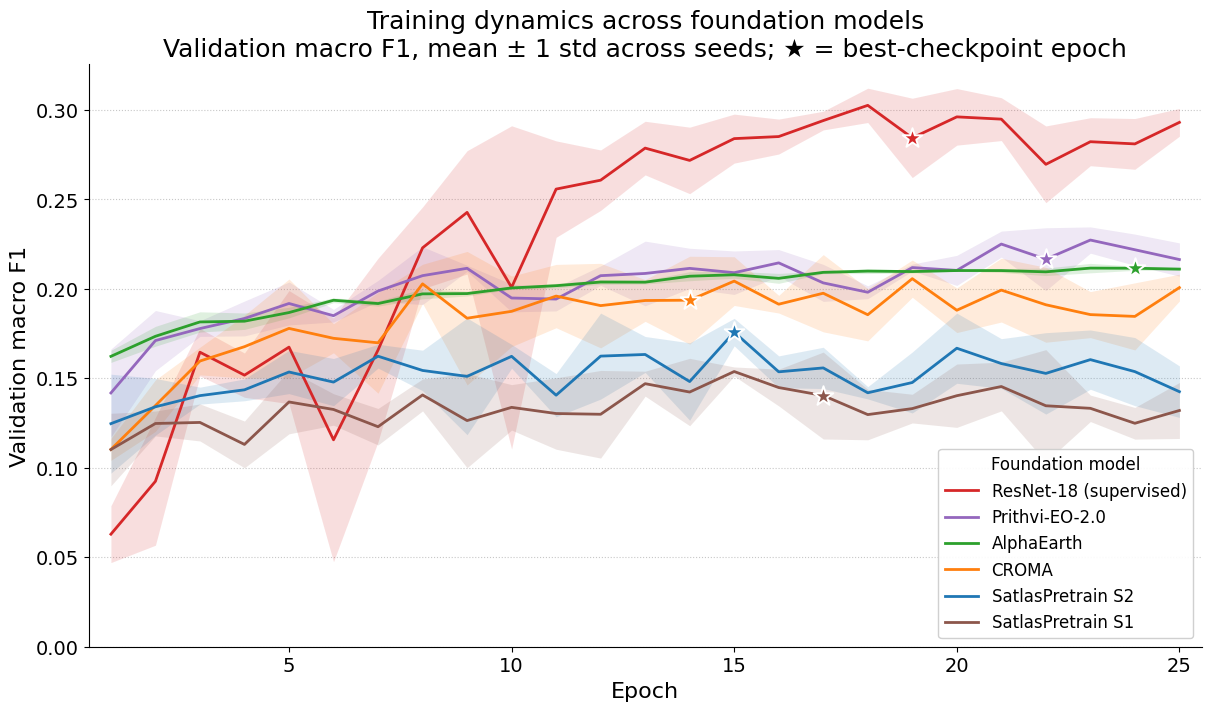


--- Best-checkpoint epochs (val macro F1 argmax) ---
  ResNet-18 (supervised)      per-seed: {314: 20, 271: 18, 161: 19}   mean best epoch: 19   peak mean F1: 0.303
  Prithvi-EO-2.0              per-seed: {314: 21, 271: 23, 161: 22}   mean best epoch: 22   peak mean F1: 0.227
  AlphaEarth                  per-seed: {314: 23, 271: 25, 161: 23}   mean best epoch: 24   peak mean F1: 0.212
  CROMA                       per-seed: {314: 12, 271: 15, 161: 14}   mean best epoch: 14   peak mean F1: 0.206
  SatlasPretrain S2           per-seed: {314: 20, 271: 15, 161: 9}   mean best epoch: 15   peak mean F1: 0.176
  SatlasPretrain S1           per-seed: {314: 22, 271: 16, 161: 14}   mean best epoch: 17   peak mean F1: 0.154


In [38]:
# Option B (final): single overlay of all six FMs, val_macro_f1 only.
# Renders inline AND saves to Drive as the Appendix A figure.
# File: /content/drive/MyDrive/infra_fm/results/appendix_A_training_dynamics_overlay.png
fig, curves = plot_training_dynamics_overlay(
    save_path=RESULTS_BASE / 'appendix_A_training_dynamics_overlay.png',
)